In [1]:
from glob import glob
from analysis_utlis import *
from other_utlis import *

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

### P_app prediction with Hybrid LGFE profiles

#### 1. FCNN

#### 1. A. Is there a better FCNN architecture? 

TLDR : Not really, the archs under this study are not significantly different in performance (using non-parameteric testing) - irrespective of what kind of data spliting strategy used

In [4]:
memb_csv_files = [["../ml-modeling-P_app_lgfe_biogen_extended_with_protomers/evaluation/FCNN/evaluation_popc_chol.csv"],
                  ["../ml-modeling-P_app_lgfe_biogen_extended_with_protomers/evaluation/FCNN/evaluation_popc_chol_halogen.csv"],
                  ["../ml-modeling-P_app_lgfe_biogen_extended_with_protomers/evaluation/FCNN/evaluation_pampa.csv"],
                  ["../ml-modeling-P_app_lgfe_biogen_extended_with_protomers/evaluation/FCNN/evaluation_bbb.csv"]]


       split       metric  levene_pvalue  max_over_min
0     butina           R2       0.127820      3.278359
1     butina         RMSE       0.698081      1.554449
2     butina          MAE       0.007392      3.952154
3     butina     PearsonR       0.393370      2.234697
4     butina  SpearmanRho       0.106095      4.485189
5     random           R2       0.123622     10.515005
6     random         RMSE       0.377097      3.279536
7     random          MAE       0.406739      3.328698
8     random     PearsonR       0.048792     14.229729
9     random  SpearmanRho       0.012036     17.898061
10  scaffold           R2       0.256699     13.082862
11  scaffold         RMSE       0.541878      2.318092
12  scaffold          MAE       0.706731      4.038678
13  scaffold     PearsonR       0.456192      2.401502
14  scaffold  SpearmanRho       0.419303      2.653527
       split       metric  levene_pvalue  max_over_min
0     butina           R2       0.178378      3.003137
1     buti

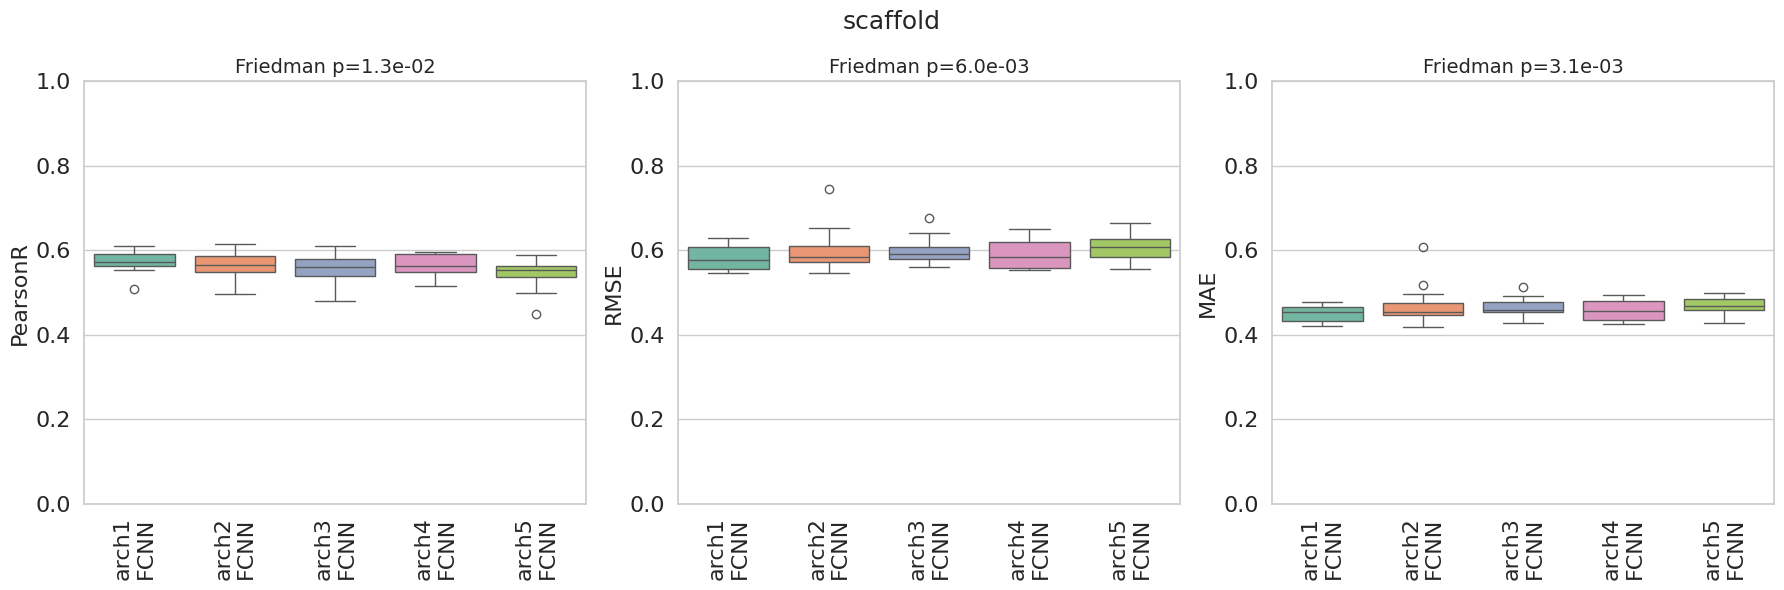

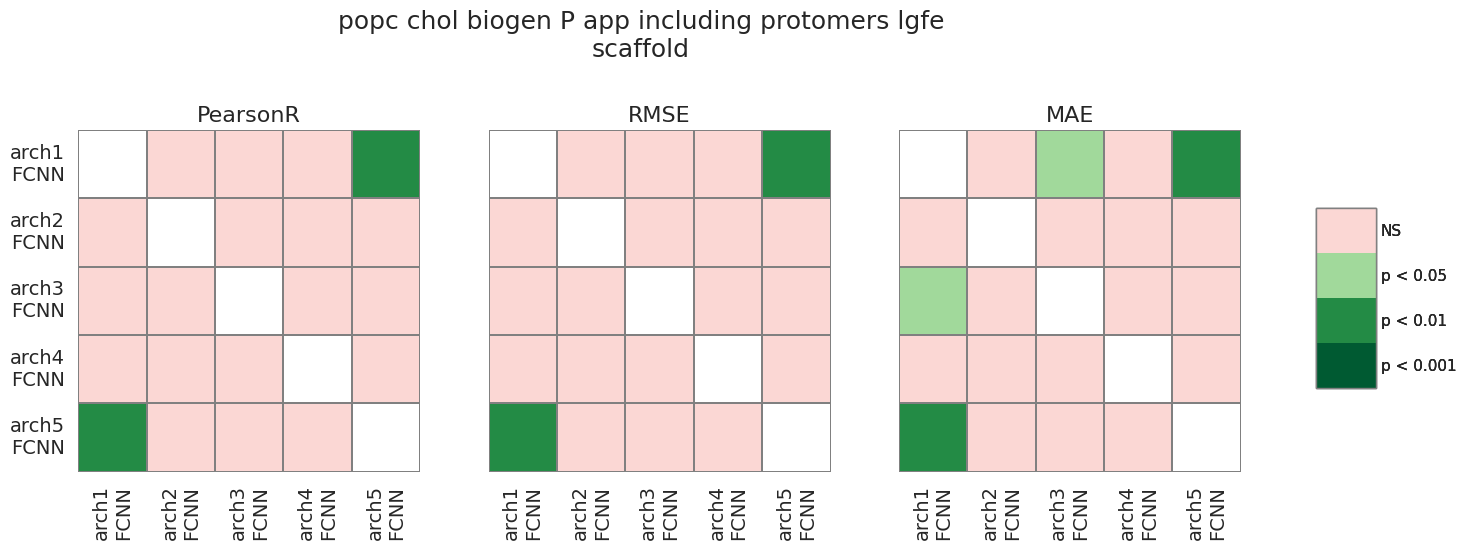

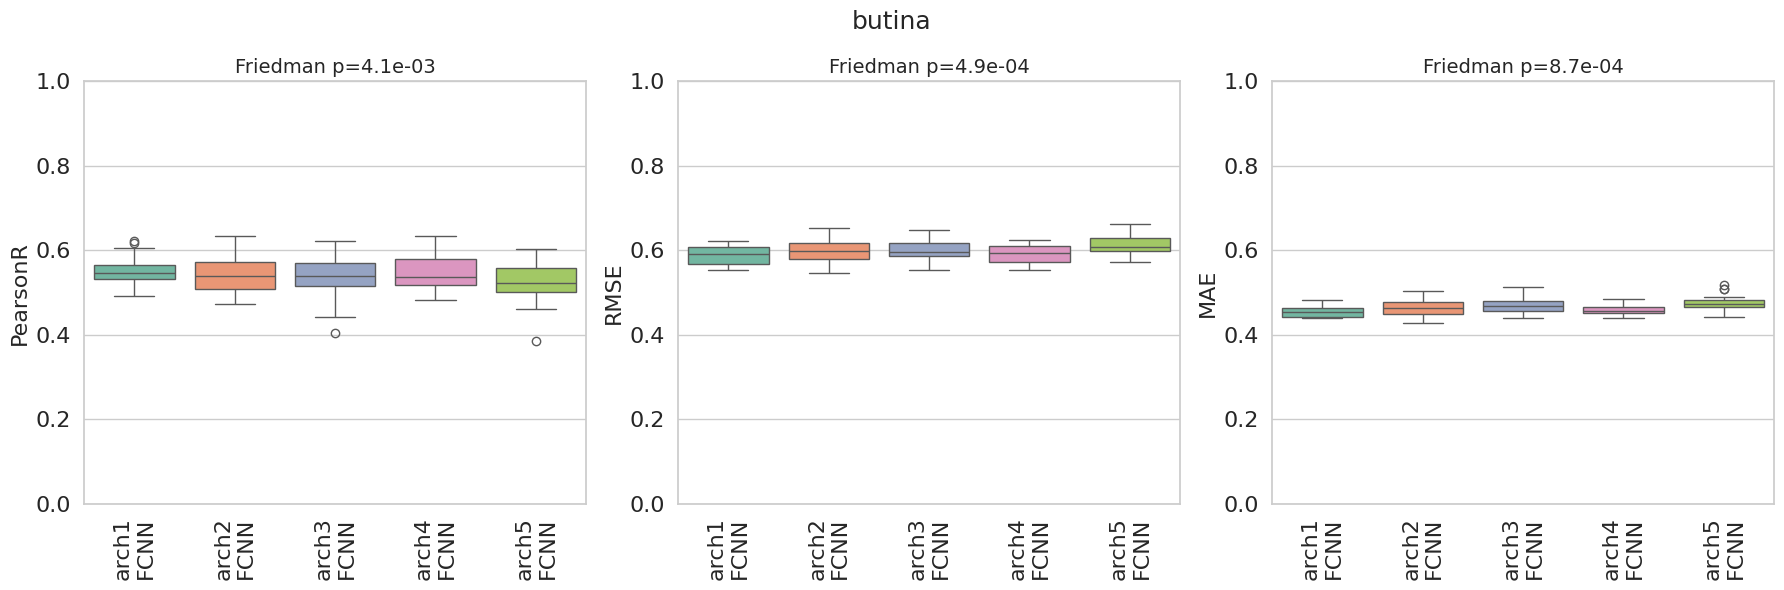

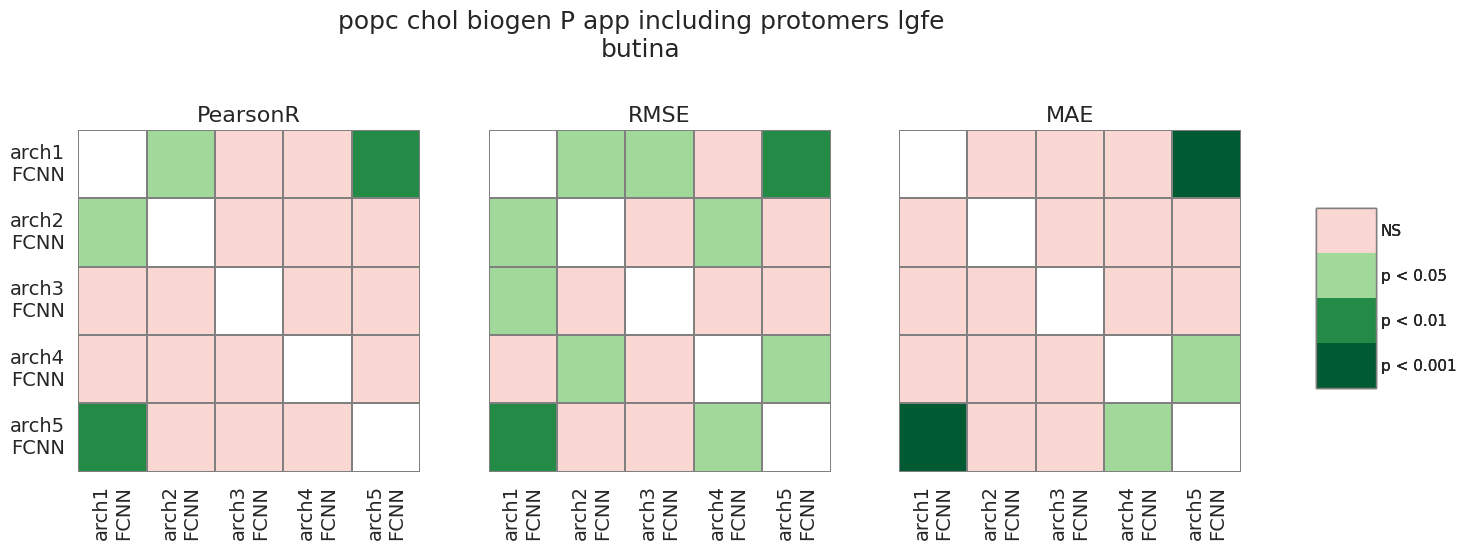

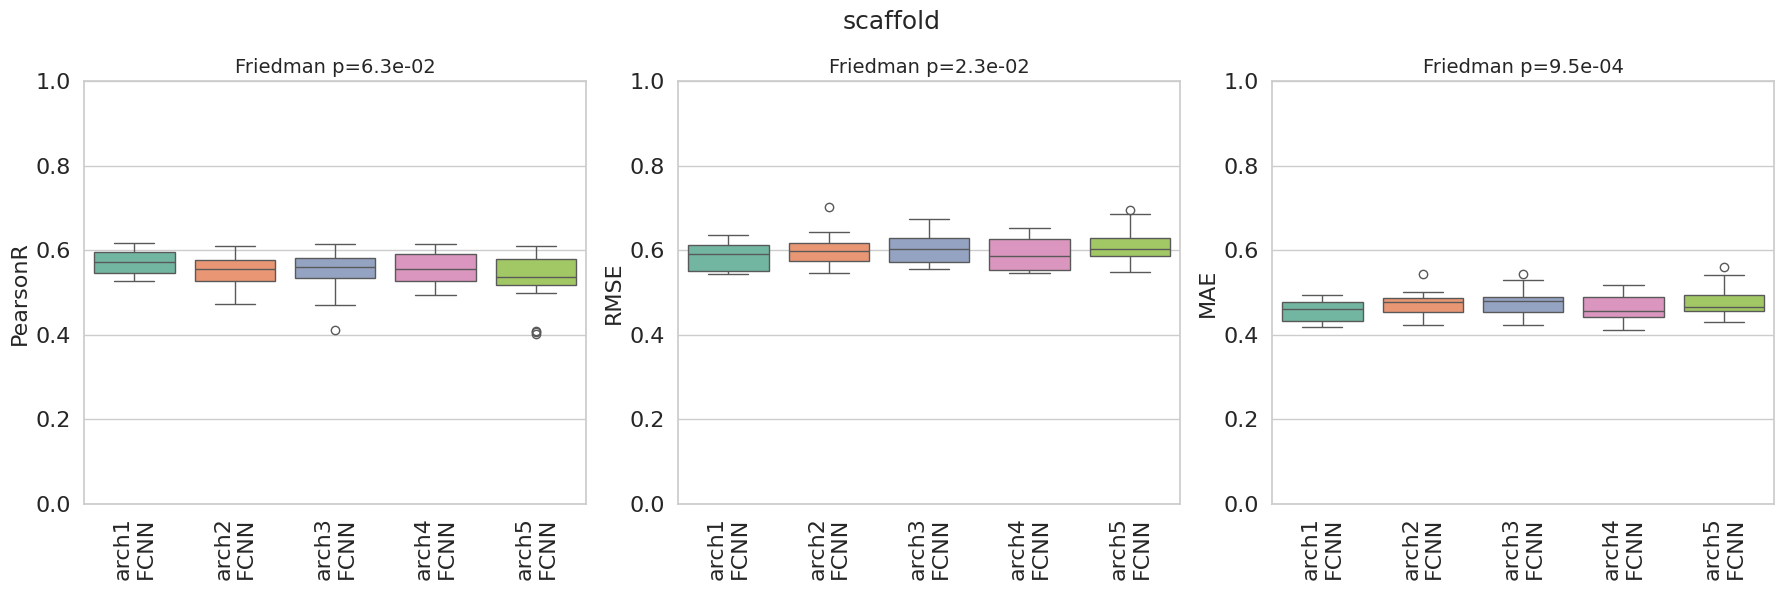

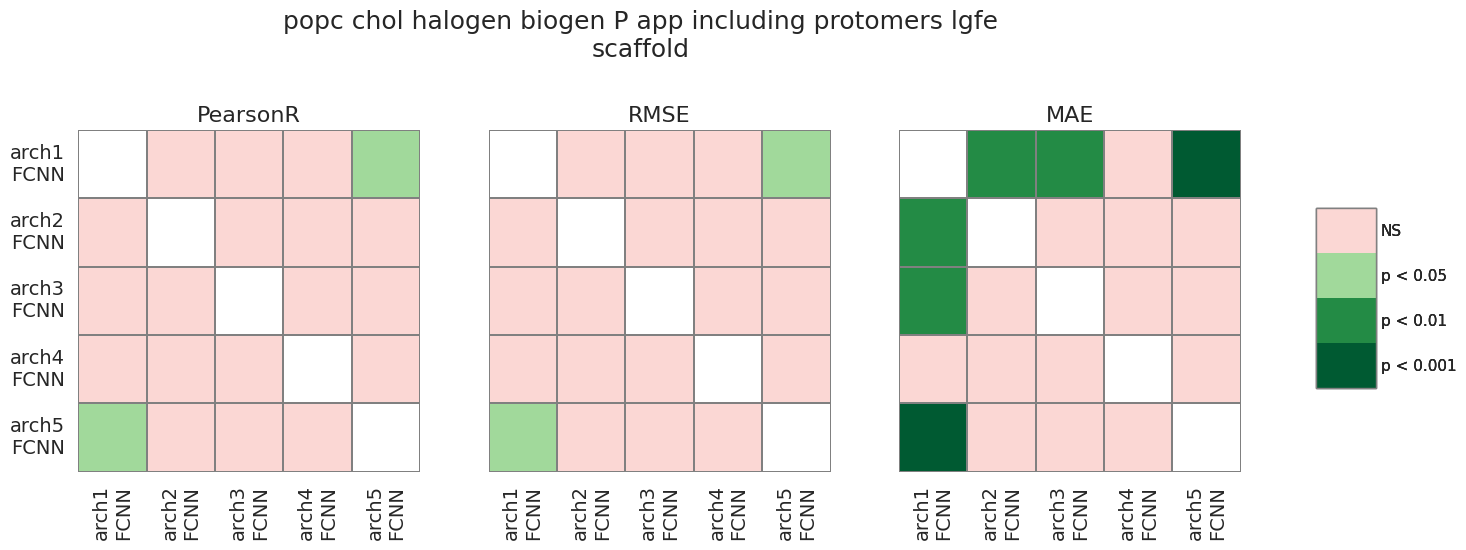

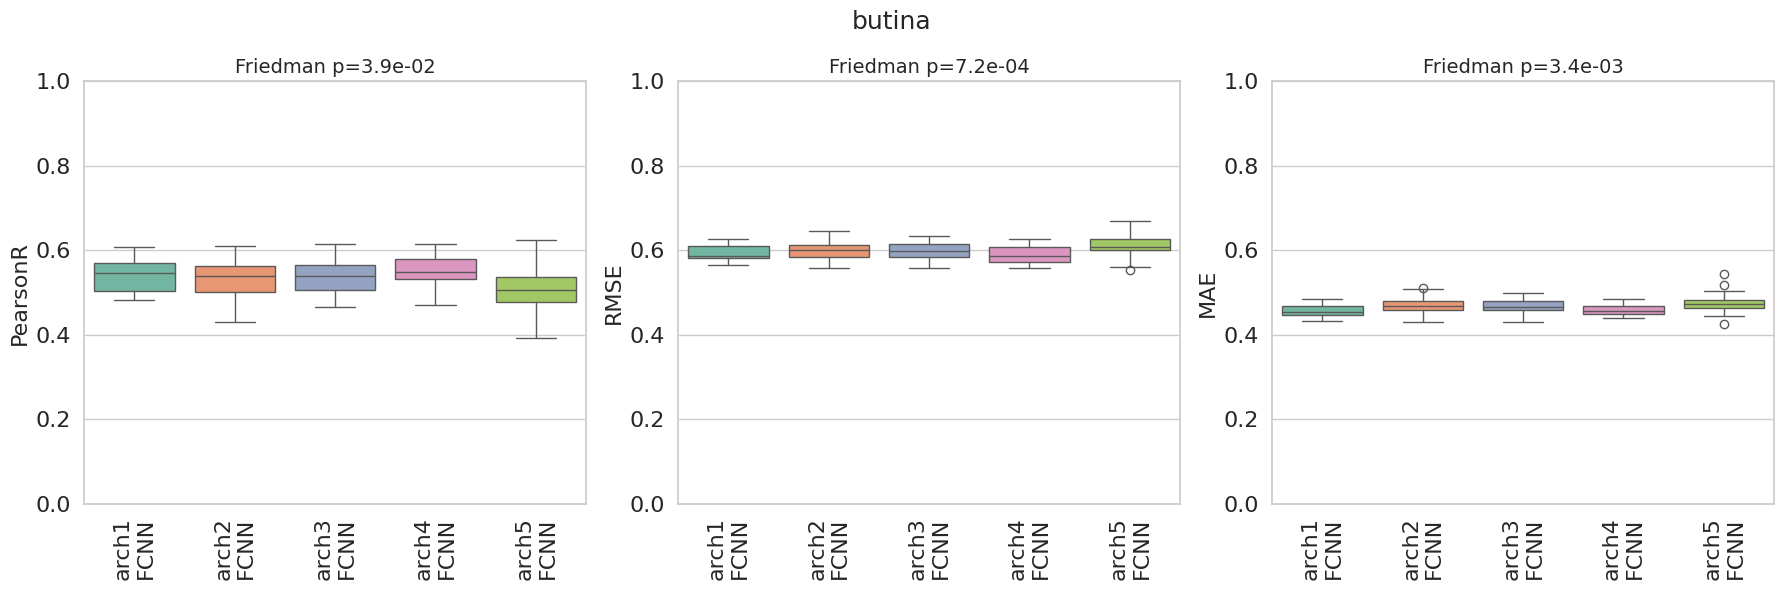

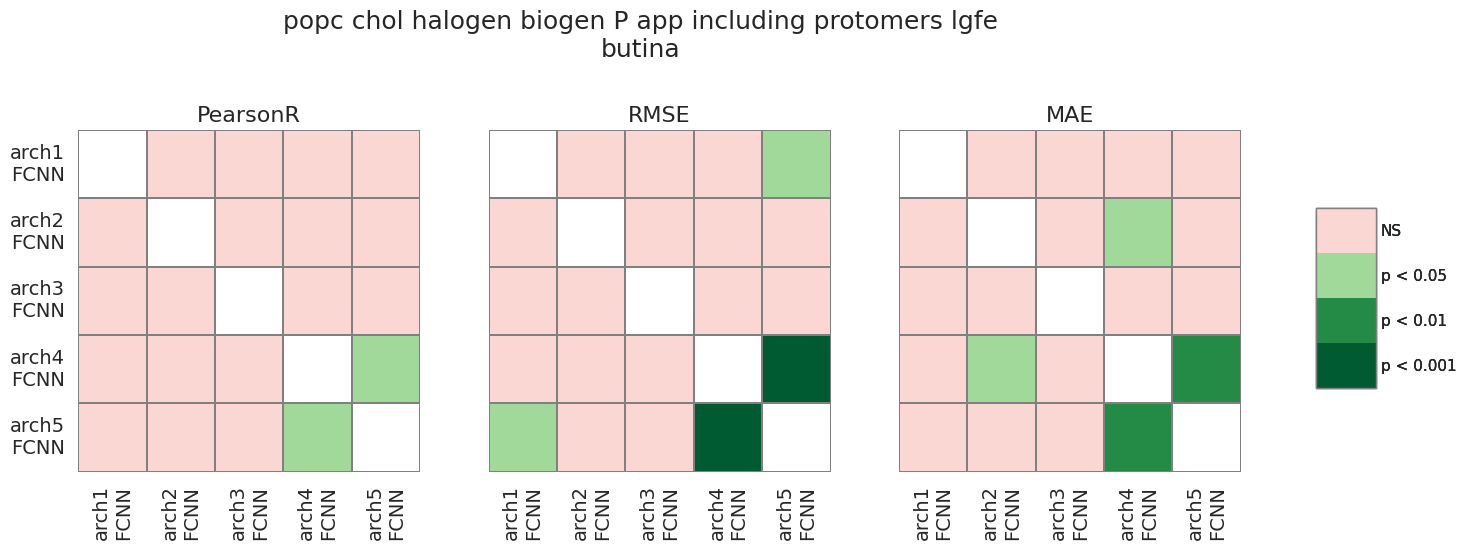

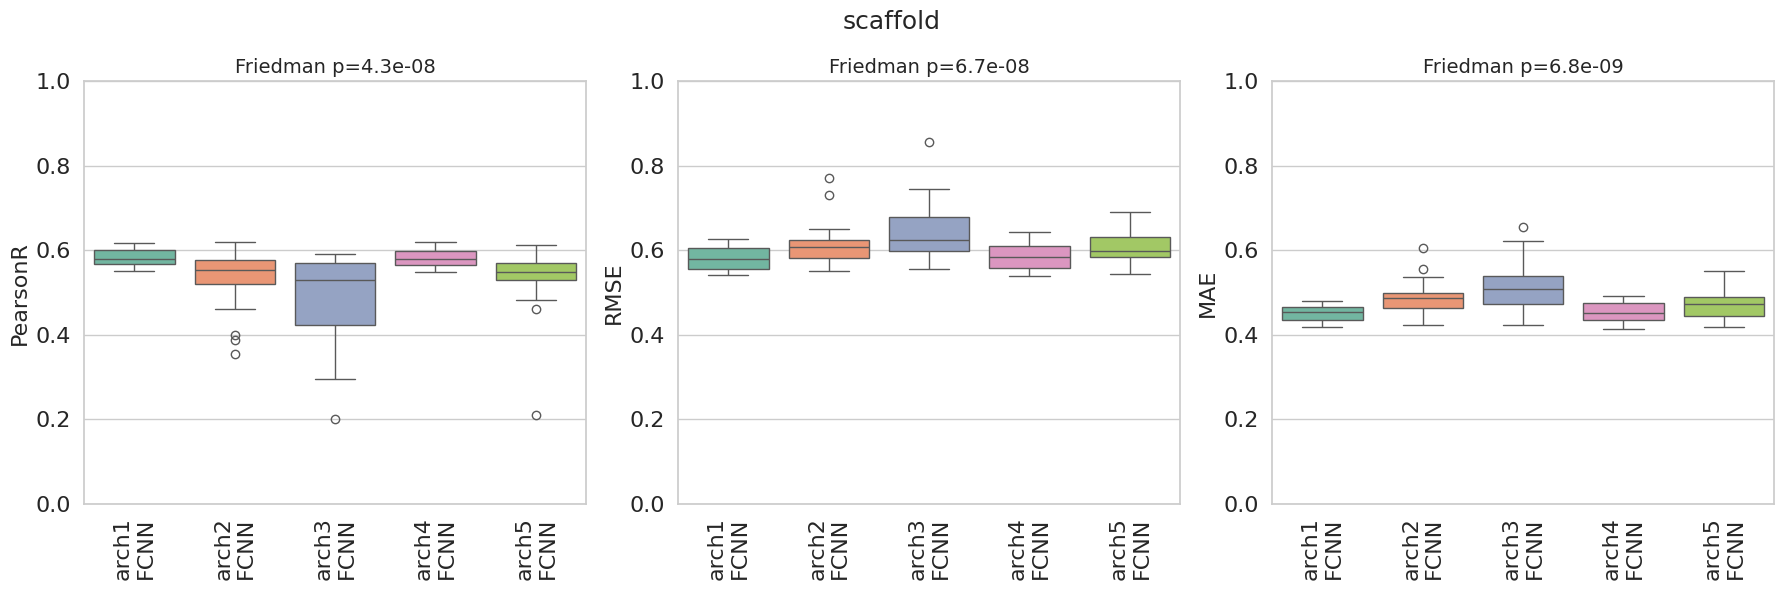

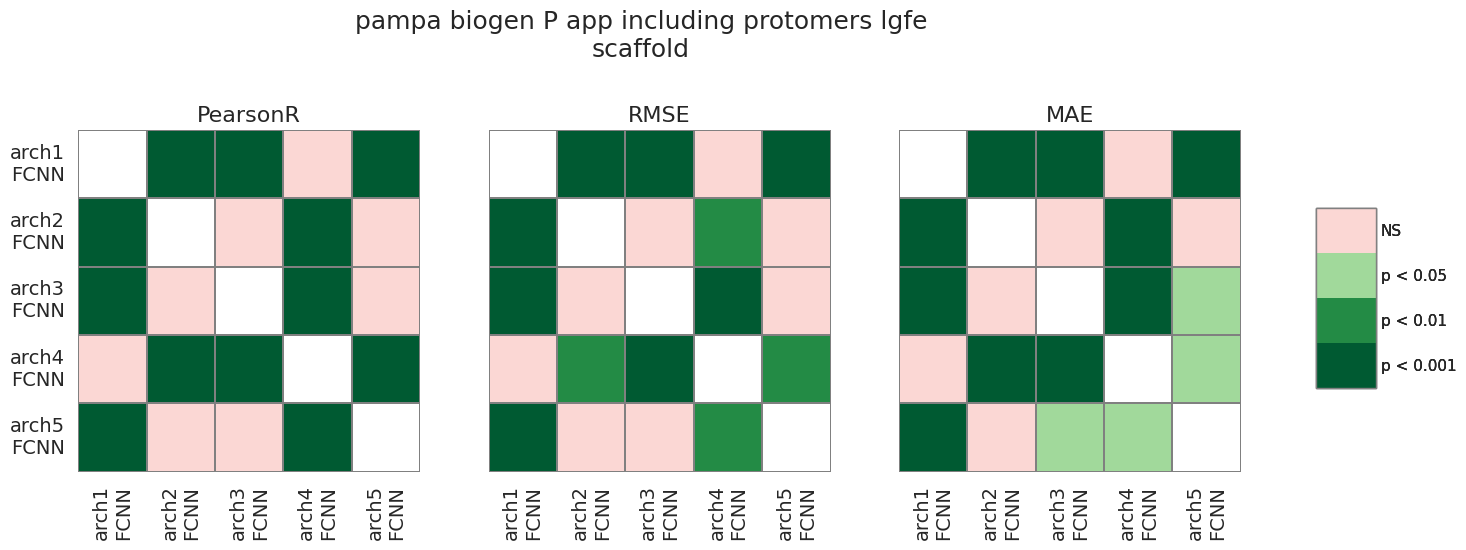

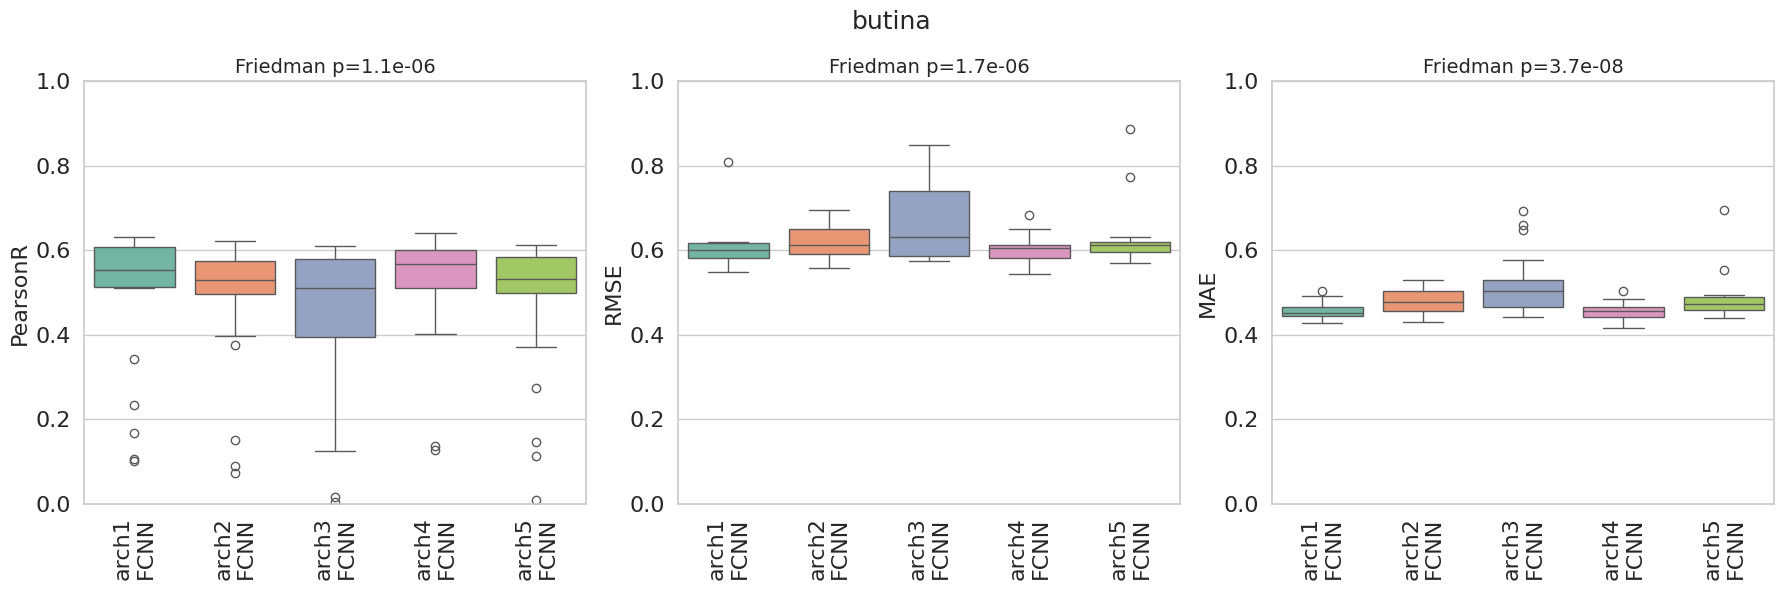

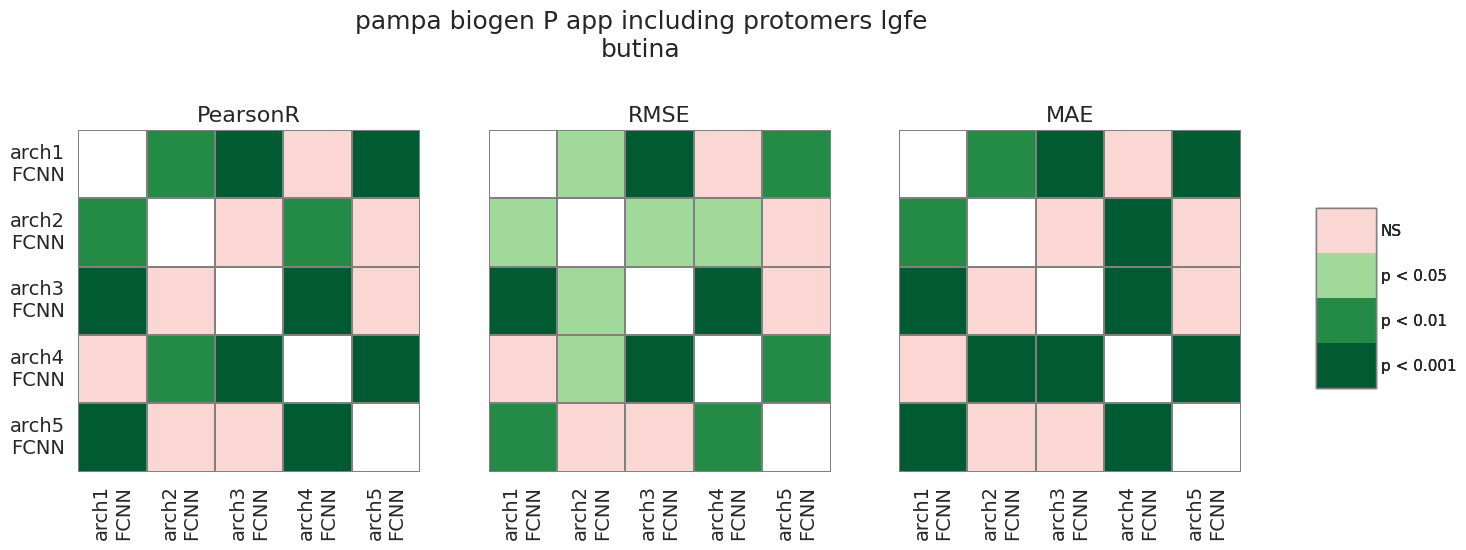

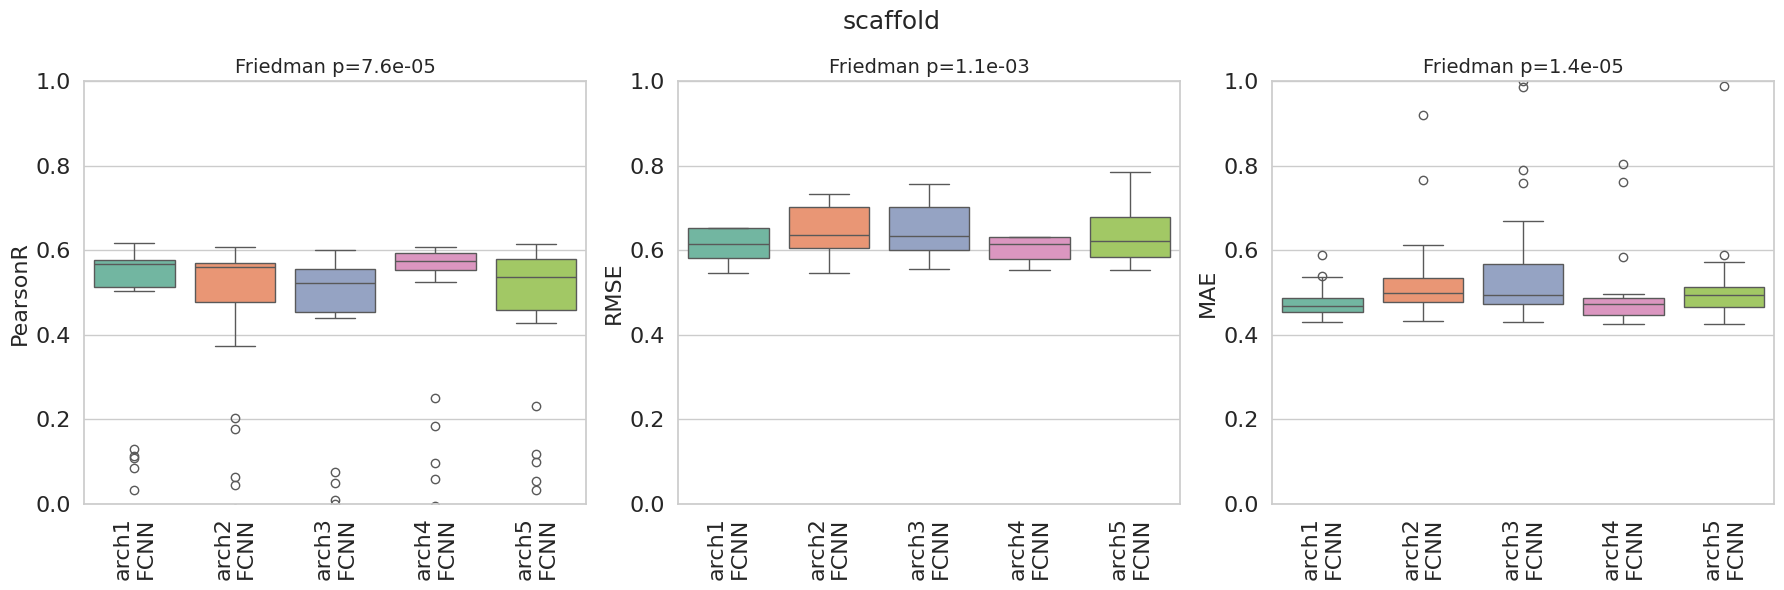

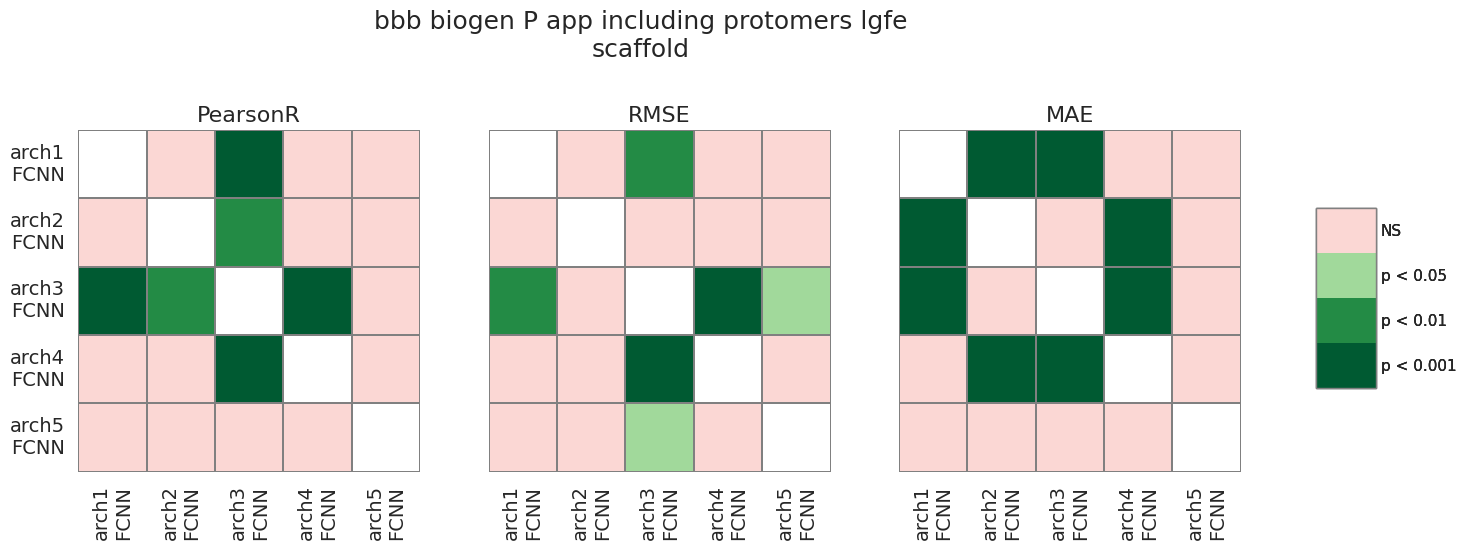

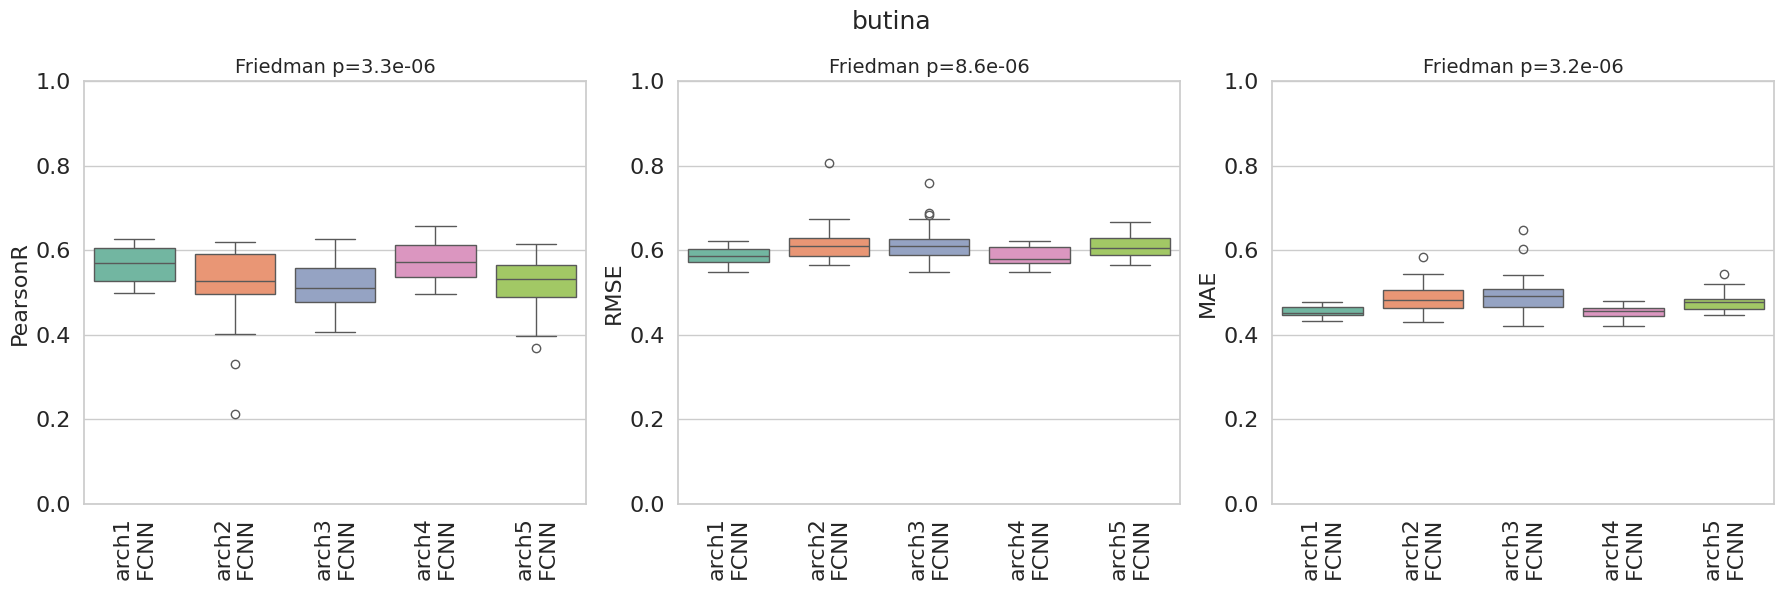

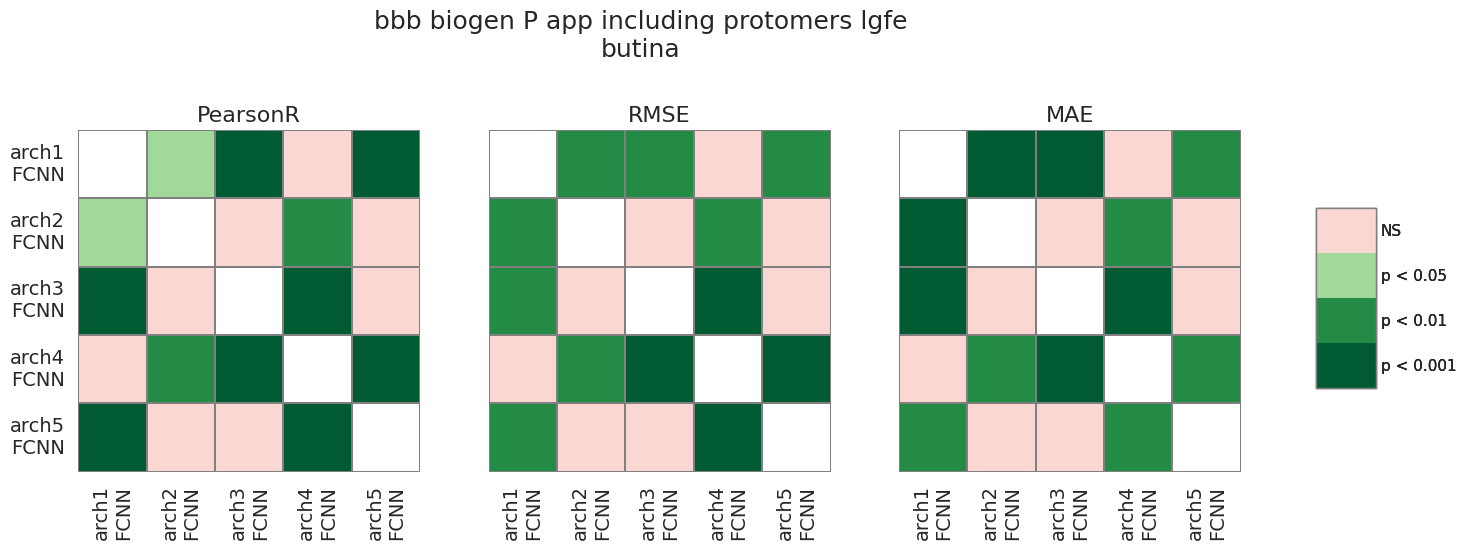

In [6]:
for csv_file in memb_csv_files:
    df = concat_metric_files(csv_file)
    metric_ls_full = ['R2', 'RMSE', 'MAE', 'PearsonR', 'SpearmanRho']
    levene_variance_df = variance_analysis_by_split(df, metric_ls_full)
    # print (Path(csv_file[0]).name)
    print (levene_variance_df)
    metric_ls = ['PearsonR', 'RMSE', 'MAE']
    split_ls = ['scaffold', 'butina'] 
    for split in split_ls:
        make_boxplots_nonparametric(df.query("split == '" + split + "'"), metric_ls, prefix=split, outdir="./plots_protomers/across_fcnn_archs_P_app_protomers")
        make_sign_plots_nonparametric(df.query("split == '" + split + "'"), metric_ls, prefix=split, outdir="./plots_protomers/across_fcnn_archs_P_app_protomers")

export_levene_results_to_excel(
    memb_csv_files,
    output_excel="./plots_protomers/across_fcnn_archs_P_app_protomers/Levene_variance_results.xlsx"
)

#### 1. B. FCNN Arch 1 seems like a good choice for further comparison since it has relatively better performace metrics and lower variablility compared to other architectures tested. 

In [9]:
memb_csv_files = [["../ml-modeling-P_app_lgfe_biogen_extended_with_protomers/evaluation/FCNN-1/evaluation_*.csv"]]

      split       metric  levene_pvalue   max_over_min
0    butina           R2       0.009064    2004.485688
1    butina         RMSE       0.004529     356.320278
2    butina          MAE       0.380344       2.766031
3    butina     PearsonR       0.000399      23.359853
4    butina  SpearmanRho       0.262742       2.491246
5  scaffold           R2       0.005613  135144.836204
6  scaffold         RMSE       0.001687    1534.717027
7  scaffold          MAE       0.061686       4.438581
8  scaffold     PearsonR       0.000436     107.595709
9  scaffold  SpearmanRho       0.209627       2.228428


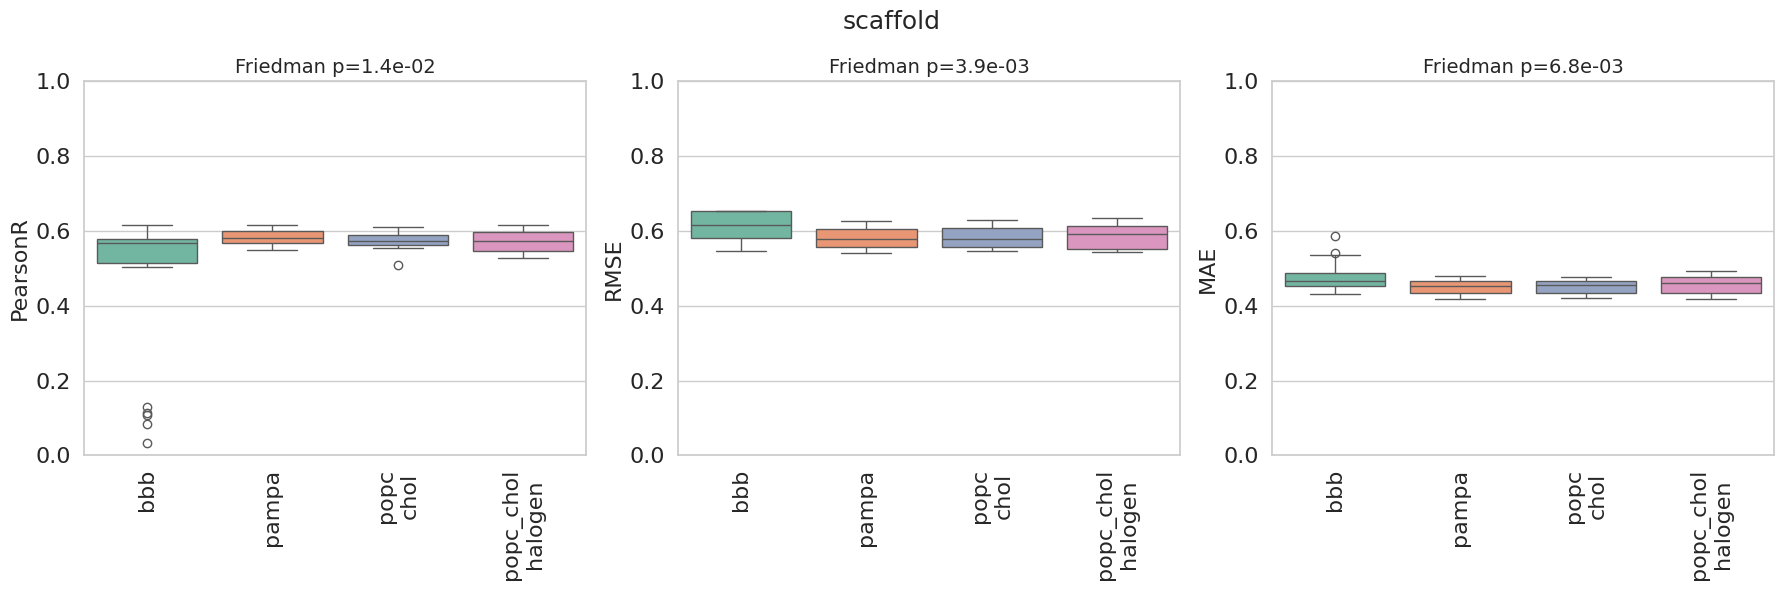

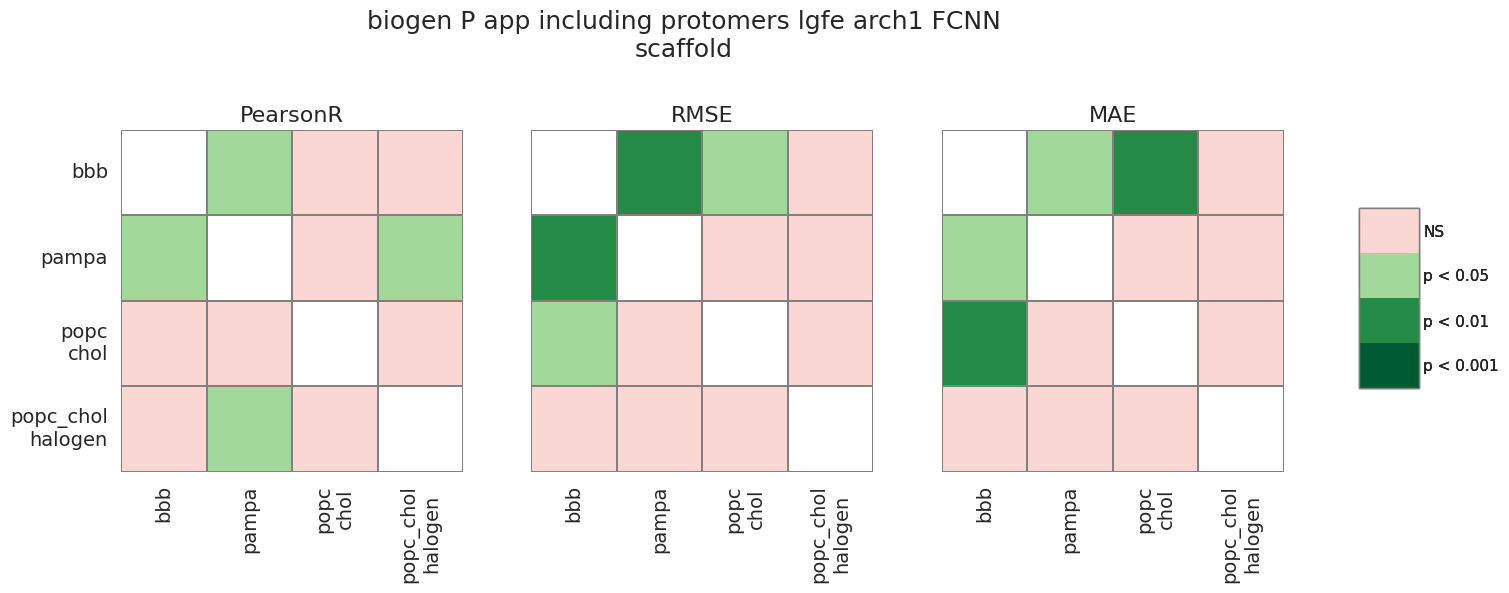

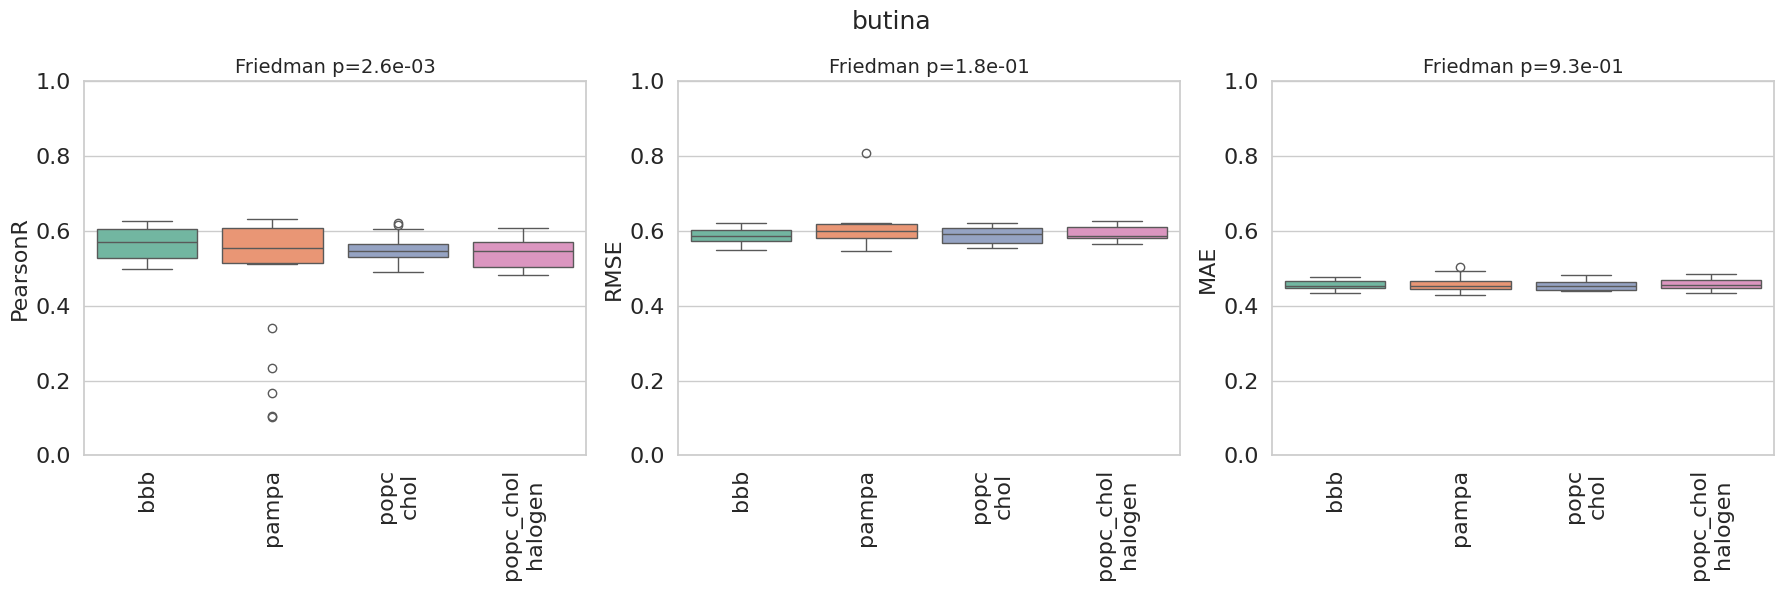

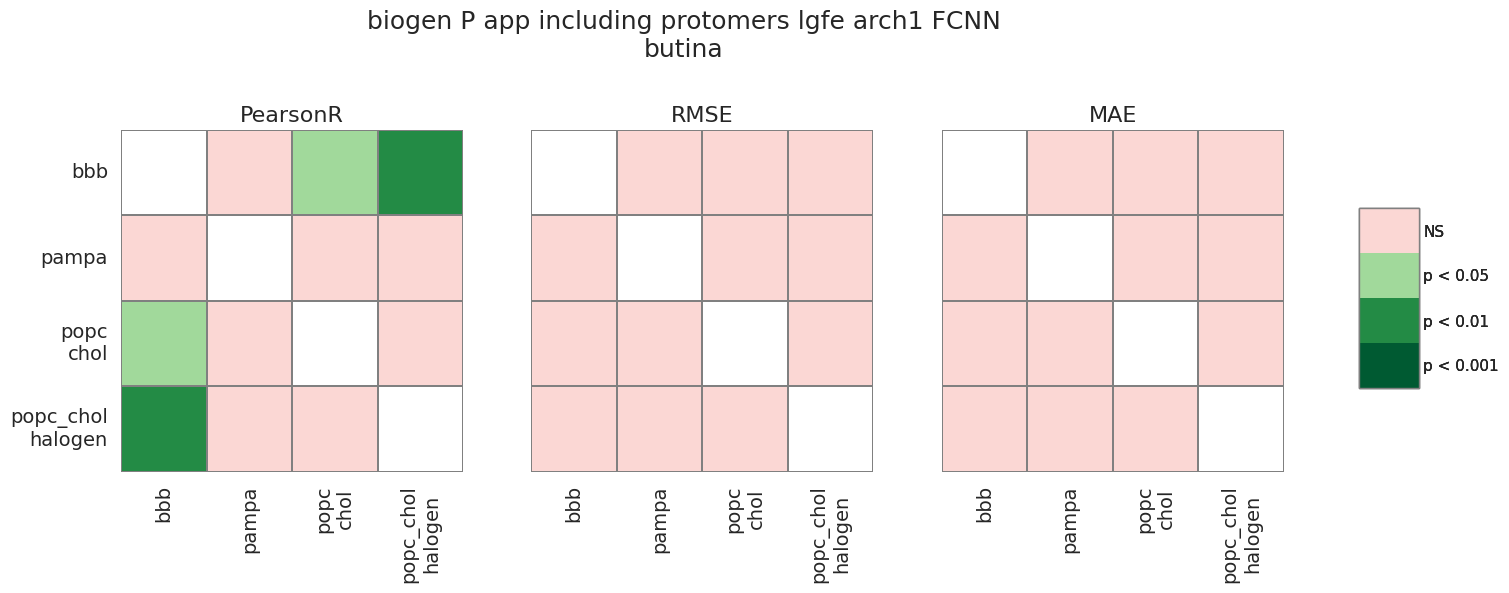

In [10]:
for csv_file in memb_csv_files:
    df = concat_metric_files(csv_file)
    metric_ls_full = ['R2', 'RMSE', 'MAE', 'PearsonR', 'SpearmanRho']
    levene_variance_df = variance_analysis_by_split(df, metric_ls_full)
    # print (Path(csv_file[0]).name)
    print (levene_variance_df)
    metric_ls = ['PearsonR', 'RMSE', 'MAE']
    split_ls = ['scaffold', 'butina'] # , 'random']
    for split in split_ls:
        make_boxplots_nonparametric(df.query("split == '" + split + "'"), metric_ls, prefix=split, outdir="./plots_protomers/fcnn1_across_membs_P_app_protomers", common_prefix="-biogen-P_app-including-protomers_lgfe_arch1_FCNN")
        make_sign_plots_nonparametric(df.query("split == '" + split + "'"), metric_ls, prefix=split, outdir="./plots_protomers/fcnn1_across_membs_P_app_protomers", common_prefix="-biogen-P_app-including-protomers_lgfe_arch1_FCNN")

export_levene_results_to_excel(
    memb_csv_files,
    output_excel="./plots_protomers/fcnn1_across_membs_P_app_protomers/Levene_variance_results.xlsx"
)

TDLR: Both PAMPA and BBB models are better than simple POPC-CHOL models in terms of FCNN method

### 2. LightGBM

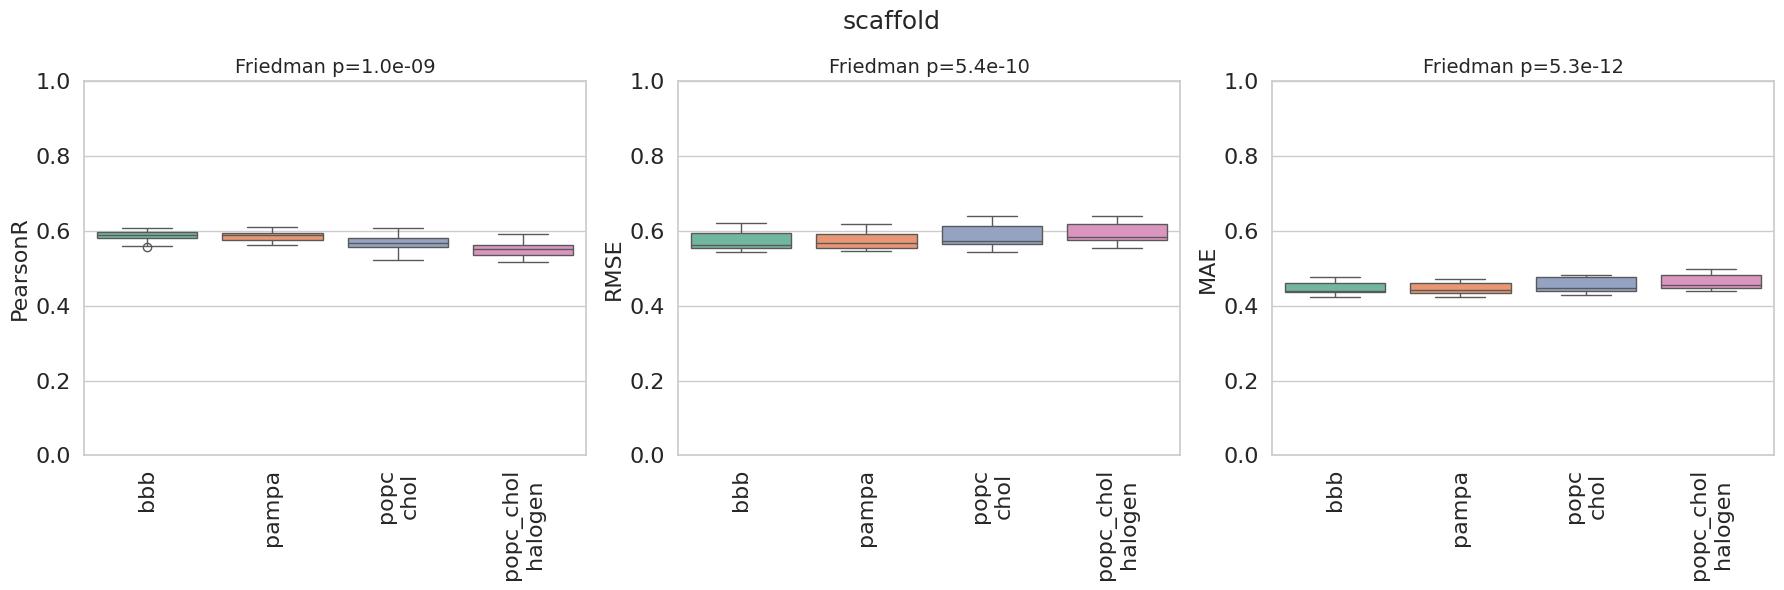

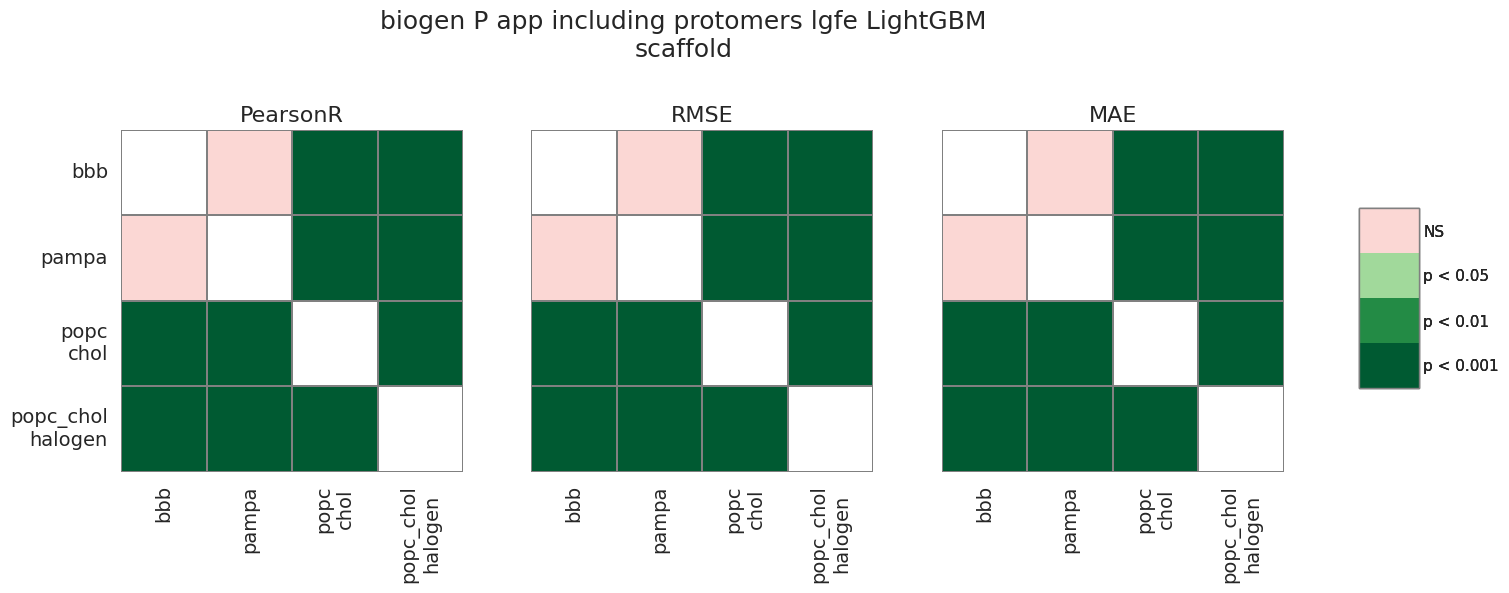

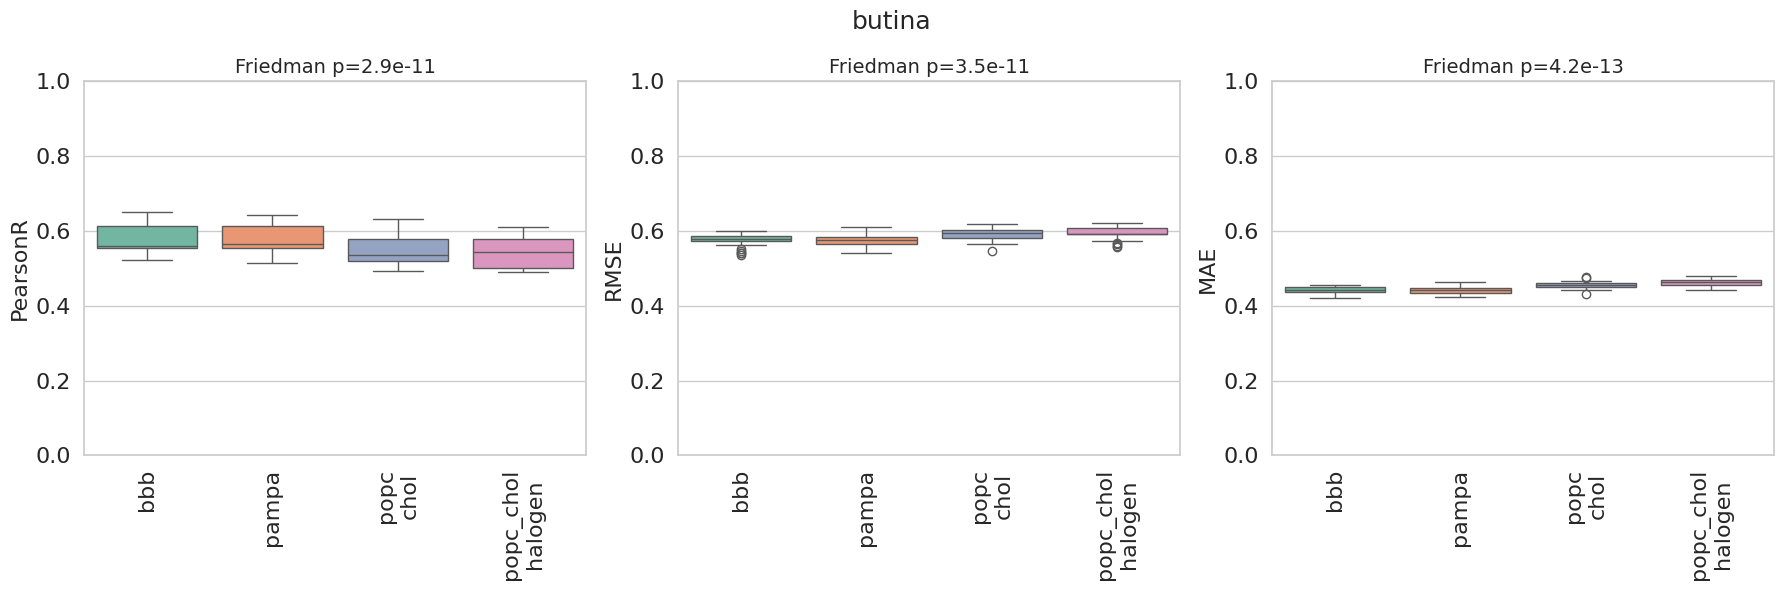

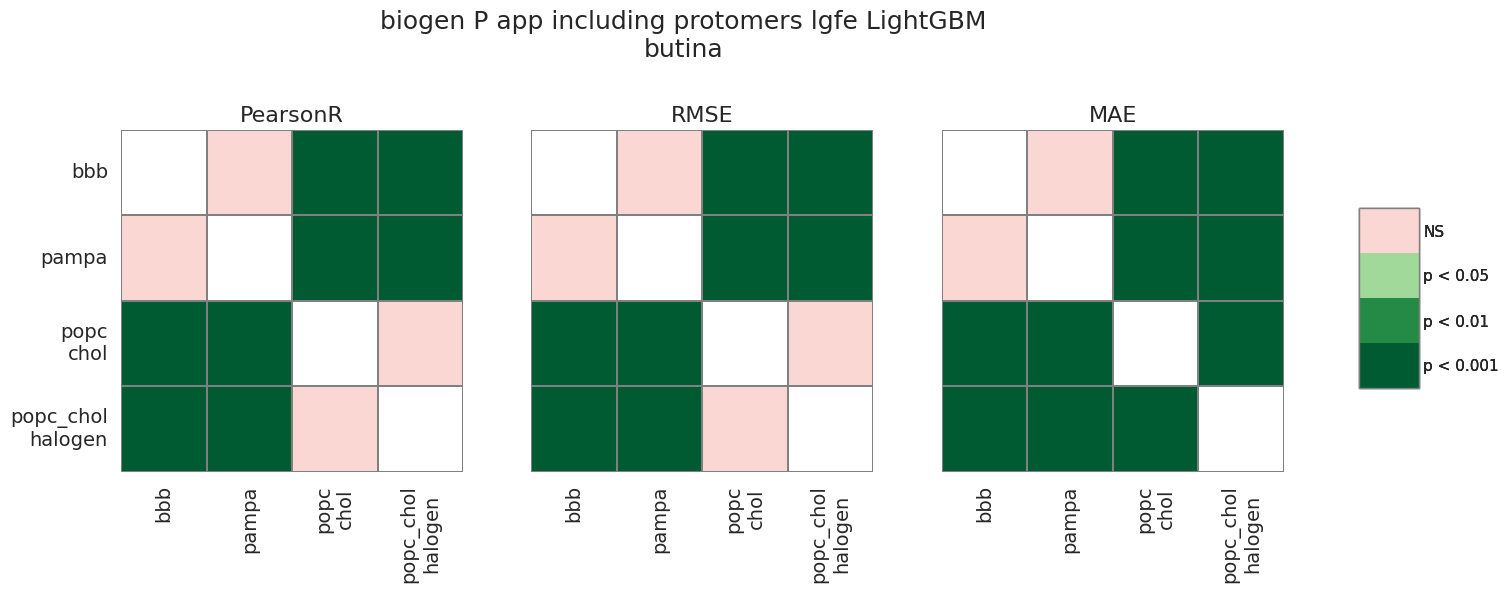

In [11]:
memb_csv_files = [["../ml-modeling-P_app_lgfe_biogen_extended_with_protomers/evaluation/LightGBM/evaluation_*.csv"]]
for csv_file in memb_csv_files:
    df = concat_metric_files(csv_file)
    # print (df.head())
    # metric_ls_full = ['R2', 'RMSE', 'MAE', 'PearsonR', 'SpearmanRho']
    # levene_variance_df = variance_analysis_by_split(df, metric_ls_full)
    # print (Path(csv_file[0]).name)
    # print (levene_variance_df)
    metric_ls = ['PearsonR', 'RMSE', 'MAE']
    split_ls = ['scaffold', 'butina'] # , 'random']
    for split in split_ls:
        make_boxplots_nonparametric(df.query("split == '" + split + "'"), metric_ls, prefix=split, outdir="./plots_protomers/lgbm_across_membs_P_app_protomers", common_prefix="-biogen-P_app-including-protomers_lgfe_LightGBM")
        make_sign_plots_nonparametric(df.query("split == '" + split + "'"), metric_ls, prefix=split, outdir="./plots_protomers/lgbm_across_membs_P_app_protomers", common_prefix="-biogen-P_app-including-protomers_lgfe_LightGBM")

export_levene_results_to_excel(
    memb_csv_files,
    output_excel="./plots_protomers/lgbm_across_membs_P_app_protomers/Levene_variance_results.xlsx"
)

TDLR : Similar to FCNN, BBB and PAMPA models are better than POPC ones. Interestingly depending on the splitting strategy, there is a significant difference in performance between halogen maps and standard maps

evaluation_*.csv
       split       metric  levene_pvalue  max_over_min
0     butina           R2       0.776569      1.410108
1     butina         RMSE       0.511106      2.096775
2     butina          MAE       0.339283      1.751144
3     butina     PearsonR       0.876885      1.379547
4     butina  SpearmanRho       0.776815      1.311934
5     random           R2       0.334984      1.899800
6     random         RMSE       0.096498      2.087405
7     random          MAE       0.498519      1.506049
8     random     PearsonR       0.369182      1.765962
9     random  SpearmanRho       0.635202      1.763687
10  scaffold           R2       0.365555      1.640655
11  scaffold         RMSE       0.783522      1.532303
12  scaffold          MAE       0.463804      1.744997
13  scaffold     PearsonR       0.349718      1.947255
14  scaffold  SpearmanRho       0.135397      2.552864


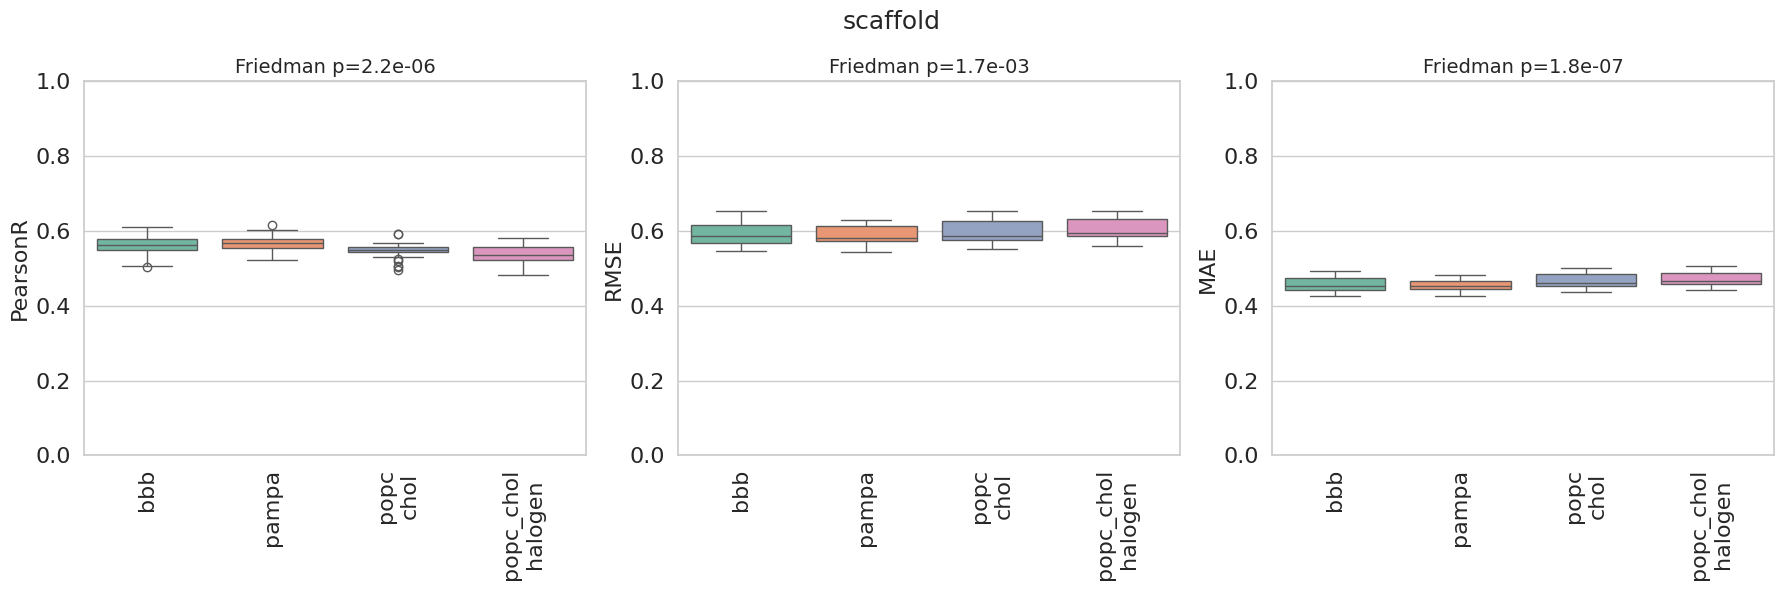

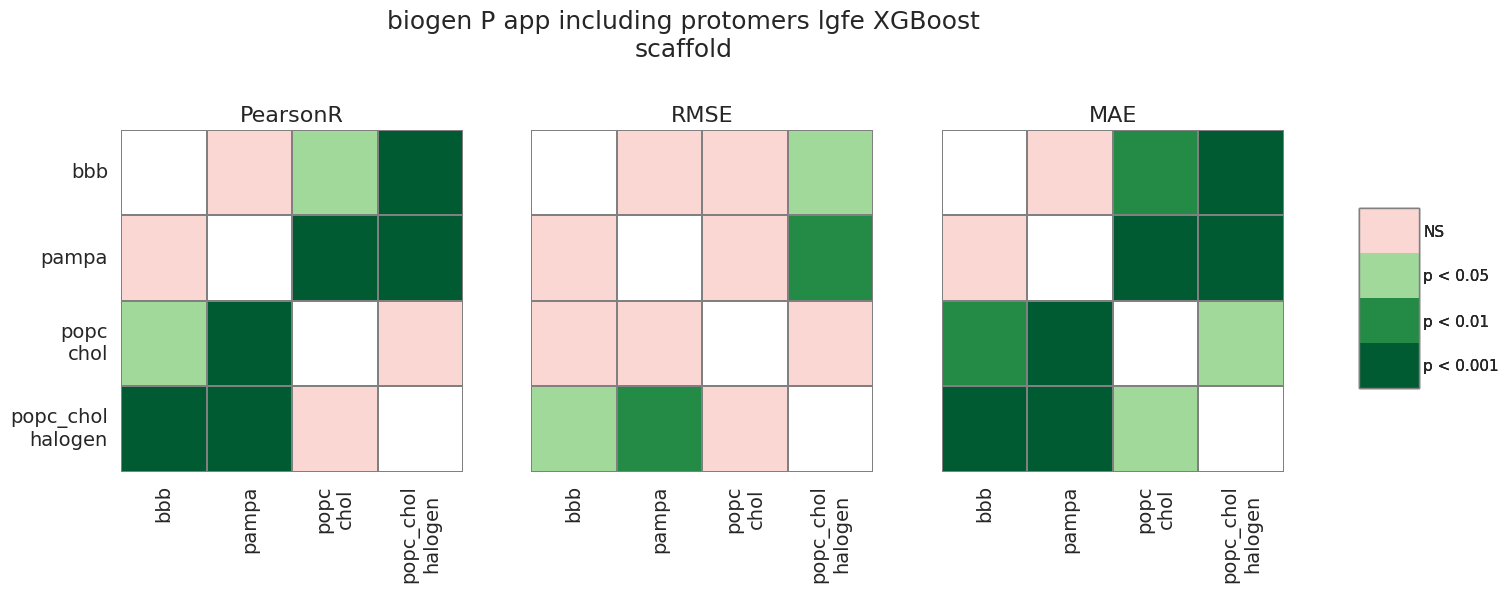

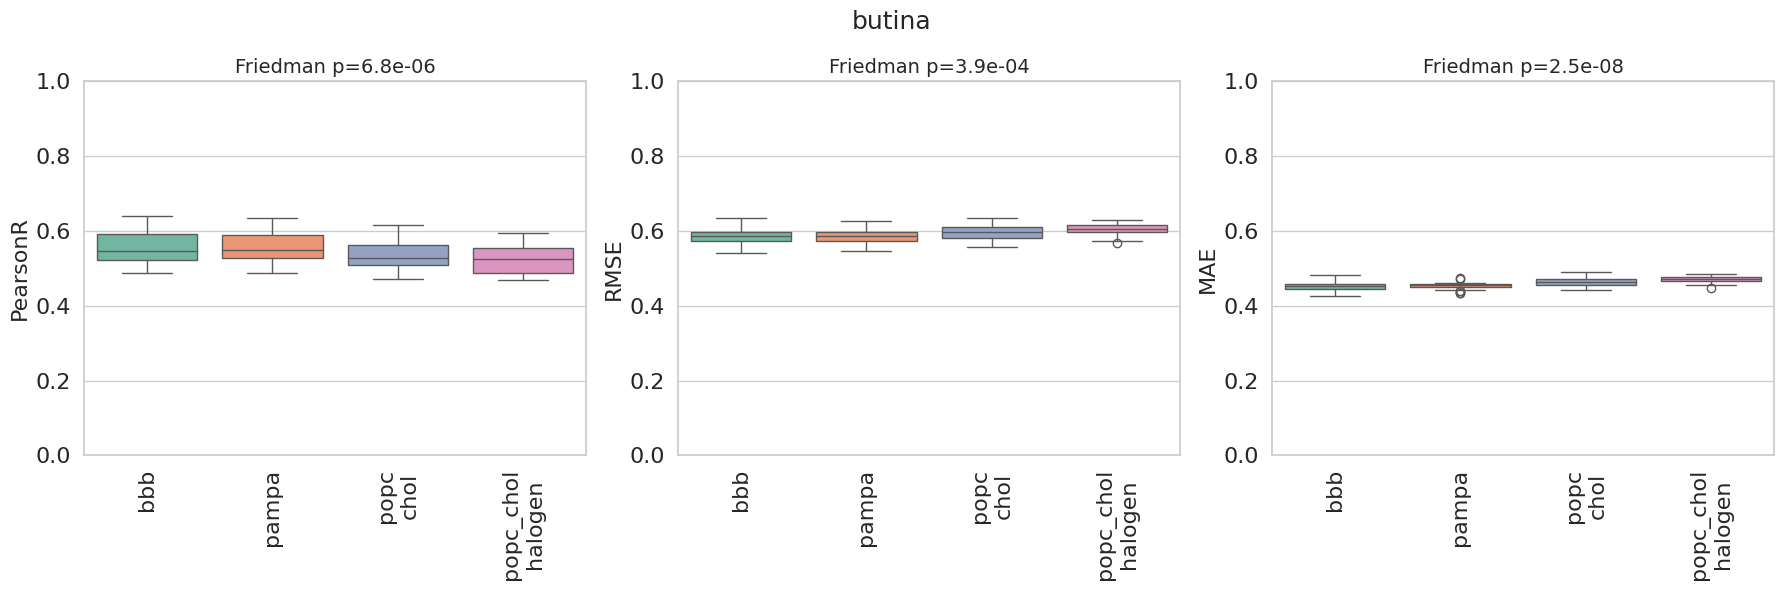

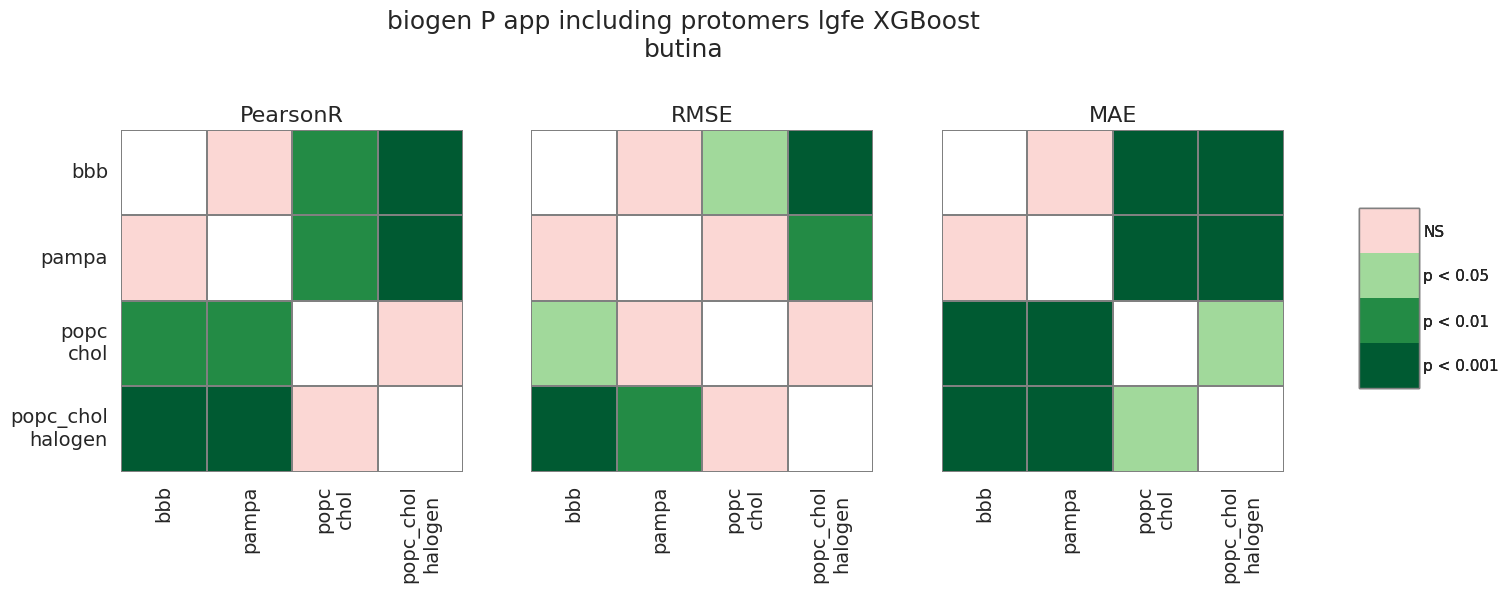

In [12]:
memb_csv_files = [["../ml-modeling-P_app_lgfe_biogen_extended_with_protomers/evaluation/XGBoost/evaluation_*.csv"]]
for csv_file in memb_csv_files:
    df = concat_metric_files(csv_file)
    # print (df.head())
    metric_ls_full = ['R2', 'RMSE', 'MAE', 'PearsonR', 'SpearmanRho']
    levene_variance_df = variance_analysis_by_split(df, metric_ls_full)
    print (Path(csv_file[0]).name)
    print (levene_variance_df)
    metric_ls = ['PearsonR', 'RMSE', 'MAE']
    split_ls = ['scaffold', 'butina'] # , 'random']
    for split in split_ls:
        make_boxplots_nonparametric(df.query("split == '" + split + "'"), metric_ls, prefix=split, outdir="./plots_protomers/xgb_across_membs_P_app_protomers", common_prefix="-biogen-P_app-including-protomers_lgfe_XGBoost")
        make_sign_plots_nonparametric(df.query("split == '" + split + "'"), metric_ls, prefix=split, outdir="./plots_protomers/xgb_across_membs_P_app_protomers", common_prefix="-biogen-P_app-including-protomers_lgfe_XGBoost")

export_levene_results_to_excel(
    memb_csv_files,
    output_excel="./plots_protomers/xgb_across_membs_P_app_protomers/Levene_variance_results.xlsx"
)

TDLR: Same story : Adding halogen maps does not really improve the performance significantly but often reduce it

### 4. How about FCNN vs ensemble learning models?

evaluation_bbb.csv
       split       metric  levene_pvalue   max_over_min
0     butina           R2   1.988200e-04    2004.485688
1     butina         RMSE   2.996888e-05     413.609447
2     butina          MAE   2.173237e-02       4.519342
3     butina     PearsonR   1.539851e-06      23.359853
4     butina  SpearmanRho   3.810359e-01       2.458270
5     random           R2   5.345412e-01       2.095992
6     random         RMSE   3.943440e-01       2.023766
7     random          MAE   6.881822e-01       1.959966
8     random     PearsonR   7.508613e-01       1.867687
9     random  SpearmanRho   2.863634e-01       3.138625
10  scaffold           R2   4.943386e-05  414223.117407
11  scaffold         RMSE   2.593894e-06    1898.961632
12  scaffold          MAE   1.334817e-02       6.365418
13  scaffold     PearsonR   4.868089e-08     212.117120
14  scaffold  SpearmanRho   6.495222e-03       6.247806


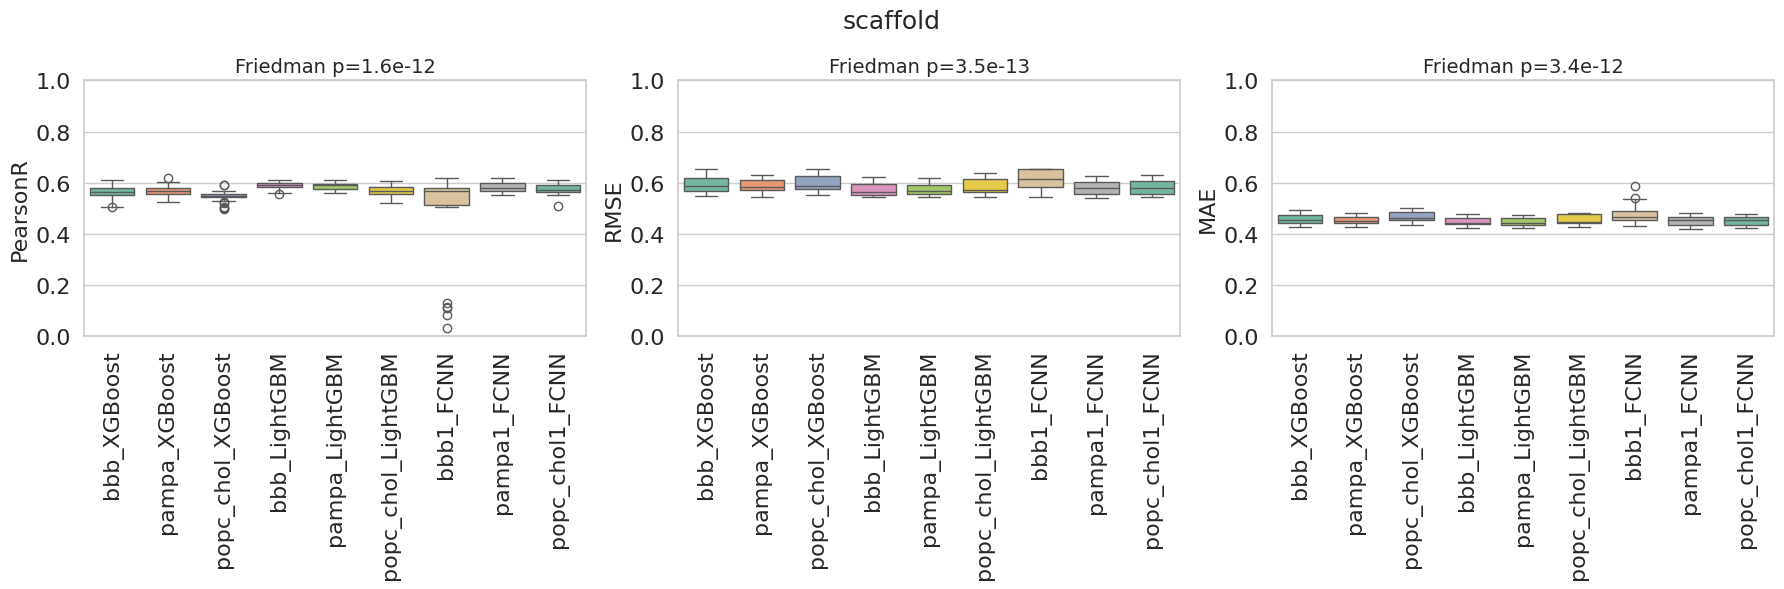

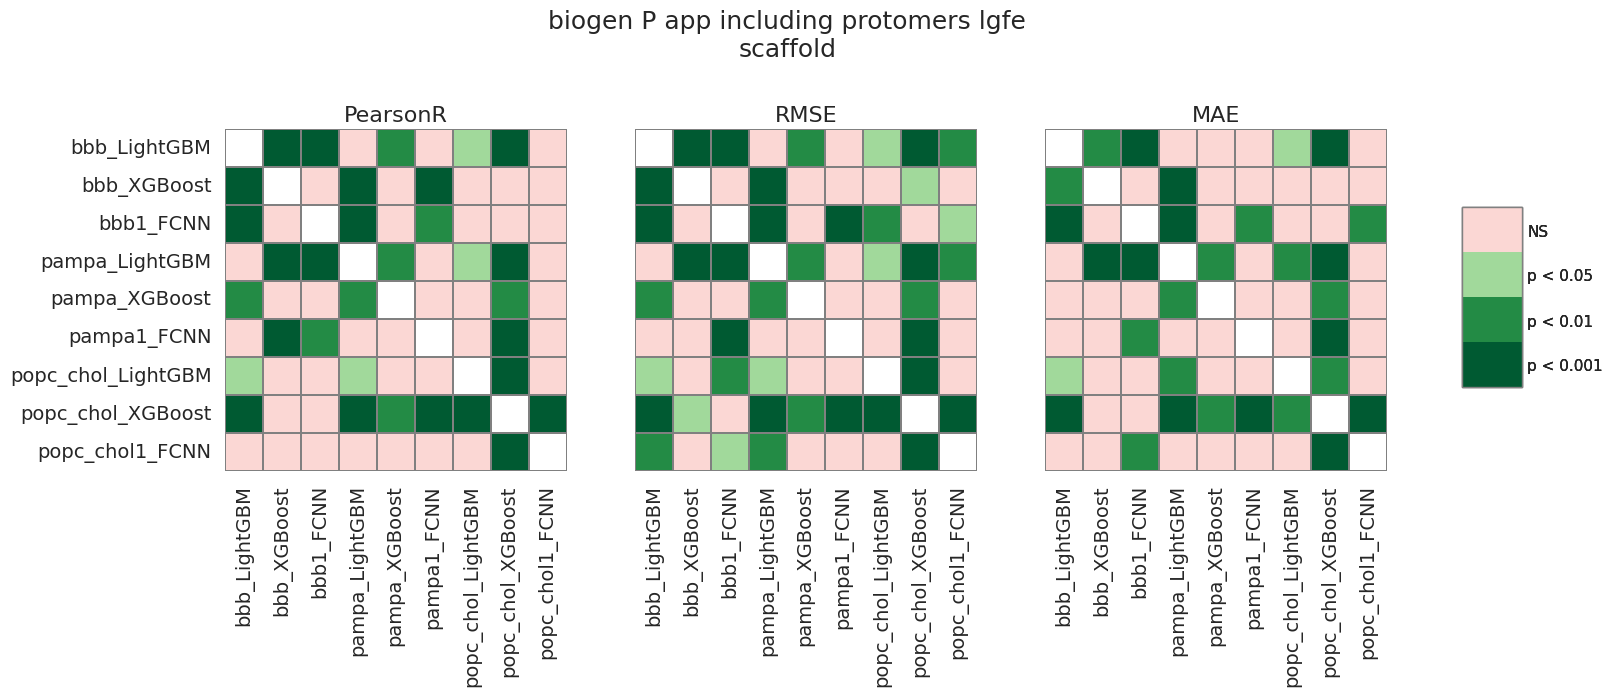

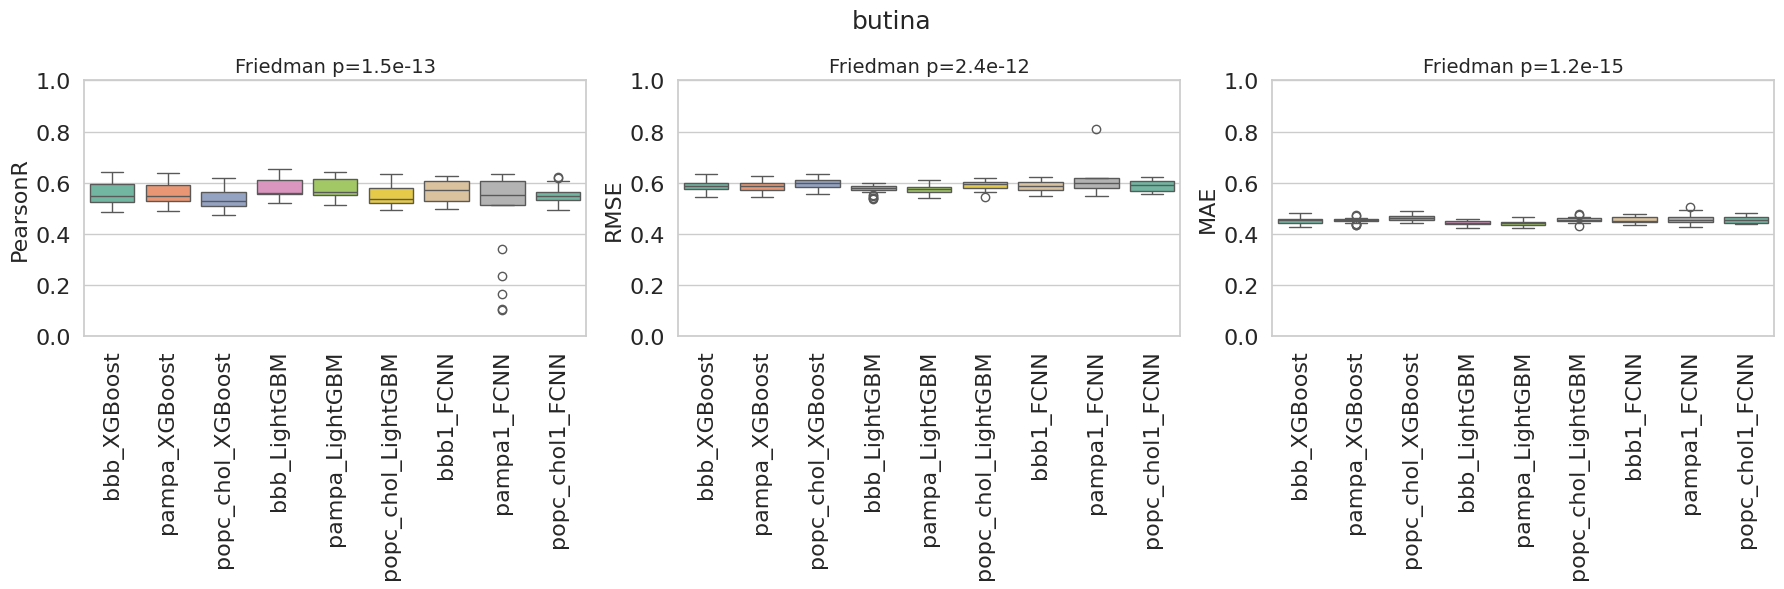

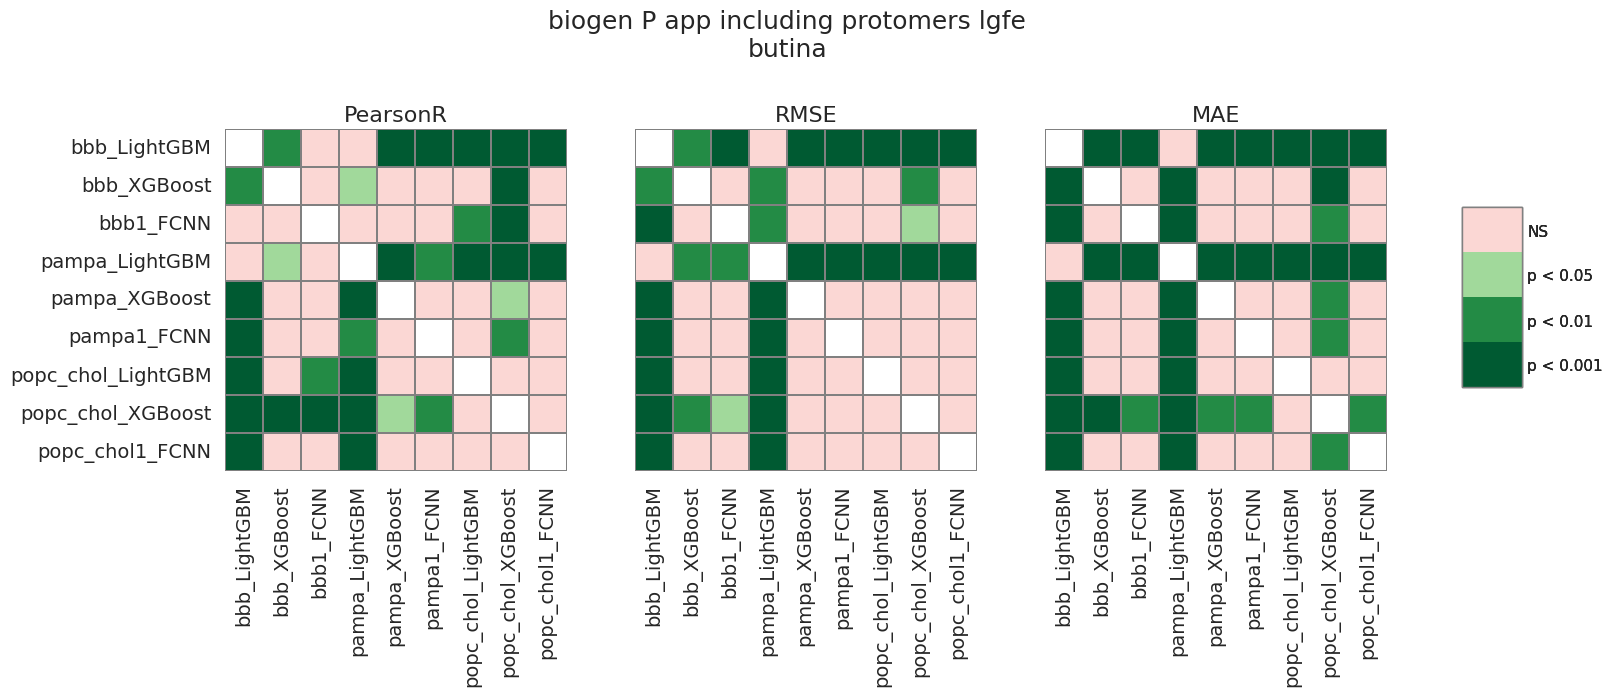

In [13]:
memb_csv_files = [["../ml-modeling-P_app_lgfe_biogen_extended_with_protomers/evaluation/XGBoost/evaluation_bbb.csv",
                   "../ml-modeling-P_app_lgfe_biogen_extended_with_protomers/evaluation/XGBoost/evaluation_pampa.csv",
                   "../ml-modeling-P_app_lgfe_biogen_extended_with_protomers/evaluation/XGBoost/evaluation_popc_chol.csv",
                  "../ml-modeling-P_app_lgfe_biogen_extended_with_protomers/evaluation/LightGBM/evaluation_bbb.csv",
                   "../ml-modeling-P_app_lgfe_biogen_extended_with_protomers/evaluation/LightGBM/evaluation_pampa.csv",
                   "../ml-modeling-P_app_lgfe_biogen_extended_with_protomers/evaluation/LightGBM/evaluation_popc_chol.csv",
                  "../ml-modeling-P_app_lgfe_biogen_extended_with_protomers/evaluation/FCNN-1/evaluation_bbb.csv",
                   "../ml-modeling-P_app_lgfe_biogen_extended_with_protomers/evaluation/FCNN-1/evaluation_pampa.csv",
                   "../ml-modeling-P_app_lgfe_biogen_extended_with_protomers/evaluation/FCNN-1/evaluation_popc_chol.csv"]]
for csv_file in memb_csv_files:
    df = concat_metric_files(csv_file)
    # print (df.head())
    metric_ls_full = ['R2', 'RMSE', 'MAE', 'PearsonR', 'SpearmanRho']
    levene_variance_df = variance_analysis_by_split(df, metric_ls_full)
    print (Path(csv_file[0]).name)
    print (levene_variance_df)
    metric_ls = ['PearsonR', 'RMSE', 'MAE']
    split_ls = ['scaffold', 'butina'] #, 'random']
    for split in split_ls:
        make_boxplots_nonparametric(df.query("split == '" + split + "'"), metric_ls, prefix=split, outdir="./plots_protomers/allmodels_across_membs_P_app_protomers", common_prefix="-biogen-P_app-including-protomers_lgfe", line_breaks=False)
        make_sign_plots_nonparametric(df.query("split == '" + split + "'"), metric_ls, prefix=split, outdir="./plots_protomers/allmodels_across_membs_P_app_protomers", common_prefix="-biogen-P_app-including-protomers_lgfe", line_breaks=False)

export_levene_results_to_excel(
    memb_csv_files,
    output_excel="./plots_protomers/allmodels_across_membs_P_app_protomers/Levene_variance_results.xlsx"
)